In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score, confusion_matrix
from scipy.special import expit
from girth import grm_mml
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.lines as mlines
import seaborn as sns
import re
import os
import warnings


warnings.filterwarnings("ignore")
# sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
sns.set_theme(style="whitegrid", context="poster", font_scale=1.5)

def save_multiformat(base_filename, directory="../figures"):
    os.makedirs(directory, exist_ok=True)
    plt.savefig(f"{directory}/{base_filename}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{directory}/{base_filename}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{directory}/{base_filename}.pdf", format='pdf', bbox_inches='tight')

In [ ]:
# ==========================================
# 0. IMPORTS
# ==========================================
import re
import warnings

import numpy as np
import pandas as pd

from scipy.special import expit
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ==========================================
# 0. CONFIGURATION & FEATURE ENGINEERING
# ==========================================
print("=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===")

DATA_FILE = "proact_preprocessed_S1.csv"

# Added the new Stan LMM to the MCMC files list
MCMC_FILES = {
    '1. LMM': "/nobackup/zwu1/gnpc_explor/new_results/results_S1_lmm_run1.csv",
    '2. Multidim Latent LMM': "/nobackup/zwu1/gnpc_explor/new_results/results_S1_mltlmm_run1.csv",
    '3. Diag OU': "../new_results/results_S1_dahlou_ncp_full_diag_run1.csv",
    '4. CLOUD': "../new_results/results_S1_dahlou_ncp_full_run1.csv"
}

df = pd.read_csv(DATA_FILE)

mcmc_dfs = {}
for name, path in MCMC_FILES.items():
    try:
        mcmc_dfs[name] = pd.read_csv(path)
    except Exception as e:
        print(f"[WARNING] Could not load {path}: {e}")

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}

all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
all_covariates = meas_covariates + dyn_covariates

# Prepare aggregations
df['Total Score'] = df[all_items].sum(axis=1)

for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

df = df.sort_values(by=['subject_id', 'ALSFRS_Delta']).reset_index(drop=True)
df['_row_id'] = np.arange(len(df))

# Feature engineering arrays needed for metric generation
X_m = df[meas_covariates].fillna(0).values
X_d = df[dyn_covariates].fillna(0).values
t_abs = (df['ALSFRS_Delta'] / 365.25).values
actual_sc = df[all_items].values

sub_map = {sub: i for i, sub in enumerate(df['subject_id'].unique())}
ID = df['subject_id'].map(sub_map).values

metrics_results = []
covariate_results = []

# ==========================================
# SAFE EXTRACTION HELPERS
# ==========================================
def add_metrics(model_name, level, target, actual, expected):
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)

    mask = ~np.isnan(expected) & ~np.isnan(actual)

    if not np.any(mask):
        return

    actual_m, expected_m = actual[mask], expected[mask]

    rmse = np.sqrt(mean_squared_error(actual_m, expected_m))
    mae = mean_absolute_error(actual_m, expected_m)

    if level == 'Item':
        pred_cat = np.clip(np.round(expected_m), 0, 4)
        exact = np.mean(pred_cat == actual_m) * 100
        try:
            kappa = cohen_kappa_score(actual_m, pred_cat, weights='linear')
        except Exception:
            kappa = np.nan
    else:
        exact, kappa = np.nan, np.nan

    metrics_results.append({
        'Model': model_name,
        'Level': level,
        'Target': target,
        'RMSE': rmse,
        'MAE': mae,
        'Exact_Match_%': exact,
        'Weighted_Kappa': kappa
    })

def ext_stan(df_m, param, shape):
    out = np.zeros(shape)
    pattern = rf"^{param}\["

    subset = df_m[df_m['Parameter'].astype(str).str.contains(pattern, regex=True)].copy()

    for _, r in subset.iterrows():
        try:
            idx_str = re.search(r'\[(.*?)\]', str(r['Parameter']))
            if not idx_str:
                continue
            idx = [int(i) - 1 for i in idx_str.group(1).split(',')]

            if len(idx) > len(shape):
                continue

            valid = True
            for j, dim_idx in enumerate(idx):
                if dim_idx >= shape[j] or dim_idx < 0:
                    valid = False
            if not valid:
                continue

            if len(idx) == 1:
                out[idx[0]] = r['Estimate']
            elif len(idx) == 2:
                out[idx[0], idx[1]] = r['Estimate']
            elif len(idx) == 3:
                out[idx[0], idx[1], idx[2]] = r['Estimate']
        except Exception:
            pass
    return out

def extract_ppp(df_m, pattern, name_mapping=None):
    subset = df_m[df_m['Parameter'].astype(str).str.contains(
        pattern, regex=True, case=False
    )].copy()

    res = {}
    for _, row in subset.iterrows():
        param = str(row['Parameter'])
        est = row['Estimate']
        idx_match = re.search(r'\[(\d+)\]', param)

        if idx_match and name_mapping:
            idx = int(idx_match.group(1)) - 1
            if idx in name_mapping:
                res[name_mapping[idx]] = est
        else:
            res[param] = est
    return res


domain_idx_full = {
    0: [0, 1, 2],
    1: [3, 4, 5],
    2: [6, 7, 8],
    3: [9, 10, 11]
}

# ==========================================
# 1. EXTRACT MCMC METRICS & COVARIATES (STAN)
# ==========================================
print("\nExtracting Stan MCMC Parameters across restricted domains...")

for model_name, df_mcmc in mcmc_dfs.items():
    print(f" -> Processing {model_name}...")

    is_3d = '3D' in model_name
    valid_k = 9 if is_3d else 12

    domain_idx = {
        0: [0, 1, 2],
        1: [3, 4, 5],
        2: [6, 7, 8]
    } if is_3d else domain_idx_full
    
    exp_sc = np.full((len(df), 12), np.nan)

    # ----------------------------------------------------
    # LINEAR MIXED MODEL (LMM) EXPECTATION CALCULATION
    # ----------------------------------------------------
    if model_name == '1. LMM':
        theta = ext_stan(df_mcmc, 'theta', (12, 4))
        beta = ext_stan(df_mcmc, 'beta', (12, 3))
        alpha_0 = ext_stan(df_mcmc, 'alpha_0', (12,))
        alpha_dyn = ext_stan(df_mcmc, 'alpha_dyn', (12, 3))
        U0 = ext_stan(df_mcmc, 'U0', (len(sub_map), 12))

        for i in range(len(df)):
            for d, items in domain_idx.items():
                for k in items:
                    eta = np.dot(X_m[i, :], beta[k]) + (alpha_0[k] + np.dot(X_d[i, :], alpha_dyn[k])) * t_abs[i] + U0[ID[i], k]
                    p = [expit(1.0 * (eta - th)) for th in theta[k]]

                    p4 = p[3]
                    p3 = p[2] - p[3]
                    p2 = p[1] - p[2]
                    p1 = p[0] - p[1]
                    p0 = 1.0 - p[0]
                    exp_sc[i, k] = (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)

    # ----------------------------------------------------
    # MULTIDIM LATENT LMM EXPECTATION CALCULATION
    # ----------------------------------------------------
    elif model_name == '2. Multidim Latent LMM':
        # Mapped to mltlmm.stan parameter names
        thresh = ext_stan(df_mcmc, 'c', (12, 4))
        lat_theta = ext_stan(df_mcmc, 'theta', (len(df), 4))
        lam = ext_stan(df_mcmc, 'lambda', (12,))
        beta = ext_stan(df_mcmc, 'beta_meas', (12, 3))

        for i in range(len(df)):
            for d, items in domain_idx.items():
                for k in items:
                    # In mltlmm.stan, latent subject effects are already folded into theta[i, d]
                    eta = np.dot(X_m[i, :], beta[k]) + lam[k] * lat_theta[i, d]
                    p = [expit(1.0 * (eta - th)) for th in thresh[k]]

                    p4 = p[3]
                    p3 = p[2] - p[3]
                    p2 = p[1] - p[2]
                    p1 = p[0] - p[1]
                    p0 = 1.0 - p[0]
                    exp_sc[i, k] = (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)
                    
    # ----------------------------------------------------
    # CLOUD AND DIAG OU EXPECTATION CALCULATION
    # ----------------------------------------------------
    else:
        # Standard CLOUD / Diag OU extraction
        theta = ext_stan(df_mcmc, 'theta', (12, 4))
        lam = ext_stan(df_mcmc, 'lambda', (12,))
        beta = ext_stan(df_mcmc, 'beta', (12, 3))
        xi = ext_stan(df_mcmc, 'xi', (4, len(df)))
        b = ext_stan(df_mcmc, 'b', (len(sub_map), 12))

        for i in range(len(df)):
            for d, items in domain_idx.items():
                for k in items:
                    eta = np.dot(X_m[i, :], beta[k]) + lam[k] * xi[d, i] + b[ID[i], k]
                    p = [expit(1.0 * (eta - th)) for th in theta[k]]

                    p4 = p[3]
                    p3 = p[2] - p[3]
                    p2 = p[1] - p[2]
                    p1 = p[0] - p[1]
                    p0 = 1.0 - p[0]
                    exp_sc[i, k] = (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)

    # Track metrics
    for k in range(valid_k):
        add_metrics(
            model_name,
            'Item',
            all_items[k],
            actual_sc[:, k],
            exp_sc[:, k]
        )

    for d, items_ in domain_idx.items():
        add_metrics(
            model_name,
            'Domain',
            list(domains.keys())[d],
            actual_sc[:, items_].sum(axis=1),
            exp_sc[:, items_].sum(axis=1)
        )

    if not is_3d:
        add_metrics(
            model_name,
            'Overall',
            'Total Score',
            actual_sc.sum(axis=1),
            exp_sc.sum(axis=1)
        )

    # Covariate Extractions
    cov_map_beta = {1: 'Sex_Female', 2: 'Treatment_Active', 3: 'Age_Base'}
    cov_map_alpha = {1: 'Bulbar_Onset', 2: 'FVC_Base', 3: 'BMI_Base'}

    # Support 'beta' for CLOUD/LMM and 'beta_meas' for mltlmm
    df_beta = df_mcmc[df_mcmc['Parameter'].astype(str).str.contains(
        r'^beta(?:_meas)?\[', regex=True
    )].copy()

    if not df_beta.empty:
        df_beta[['Dim1', 'Cov_idx']] = df_beta['Parameter'].astype(str).str.extract(
            r'\[(\d+),(\d+)\]'
        ).astype(int)

        for _, row in df_beta.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_beta:
                continue

            k_idx = int(row['Dim1']) - 1
            if k_idx >= valid_k:
                continue

            c_name = cov_map_beta[c_idx]
            item_name = all_items[k_idx]
            est = row['Estimate']
            se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)

            covariate_results.append({
                'Item': item_name,
                'Covariate': c_name,
                'Model': model_name,
                'Z_Score': est / se if se != 0 else 0.0,
                'SE': se,
                'Est': est
            })

    # Support 'alpha_dyn' for all models
    df_alpha = df_mcmc[df_mcmc['Parameter'].astype(str).str.contains(
        r'^alpha_dyn\[', regex=True
    )].copy()

    if not df_alpha.empty:
        df_alpha[['Dim1', 'Cov_idx']] = df_alpha['Parameter'].astype(str).str.extract(
            r'\[(\d+),(\d+)\]'
        ).astype(int)

        for _, row in df_alpha.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_alpha:
                continue

            c_name = cov_map_alpha[c_idx]

            # In standard LMM, Dim1 is the item index.
            if model_name == '1. LMM':
                k_idx = int(row['Dim1']) - 1
                if k_idx >= valid_k:
                    continue
                    
                item_name = all_items[k_idx]
                comp_est = row['Estimate']
                comp_se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)

                covariate_results.append({
                    'Item': item_name,
                    'Covariate': c_name,
                    'Model': model_name,
                    'Z_Score': comp_est / comp_se if comp_se != 0 else 0.0,
                    'SE': comp_se,
                    'Est': comp_est
                })
                
            # In CLOUD and mltlmm, Dim1 is the domain index.
            else:
                dom_idx = int(row['Dim1']) - 1
                if dom_idx not in domain_idx:
                    continue

                phi_est = row['Estimate']
                phi_se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)

                for k_idx in domain_idx[dom_idx]:
                    item_name = all_items[k_idx]
                    lam_k = lam[k_idx]

                    comp_est = lam_k * phi_est
                    comp_se = abs(lam_k) * phi_se

                    covariate_results.append({
                        'Item': item_name,
                        'Covariate': c_name,
                        'Model': model_name,
                        'Z_Score': comp_est / comp_se if comp_se != 0 else 0.0,
                        'SE': comp_se,
                        'Est': comp_est
                    })


# ==========================================
# 2. AGGREGATION & EXPORT
# ==========================================
print("\nAggregating Results...")

mod_order = [
    '1. LMM',
    '2. Multidim Latent LMM',
    '3. Diag OU',
    '4. CLOUD',
]

# Metrics
df_metrics = pd.DataFrame(metrics_results)

if df_metrics.empty:
    df_metrics = pd.DataFrame(columns=[
        'Model', 'Level', 'Target', 'RMSE', 'MAE', 'Exact_Match_%', 'Weighted_Kappa'
    ])
else:
    df_metrics = df_metrics.dropna(subset=['RMSE'])

df_metrics['Level'] = pd.Categorical(
    df_metrics['Level'],
    categories=['Overall', 'Domain', 'Item'],
    ordered=True
)
df_metrics.to_csv("master_predictive_metrics.csv", index=False)

# Covariates
df_covs = pd.DataFrame(covariate_results)
if df_covs.empty:
    df_covs = pd.DataFrame(columns=[
        'Item', 'Covariate', 'Model', 'Z_Score', 'SE', 'Est'
    ])

df_covs['Item'] = pd.Categorical(
    df_covs['Item'],
    categories=list(reversed(all_items)),
    ordered=True
)
df_covs['Model'] = pd.Categorical(
    df_covs['Model'],
    categories=mod_order,
    ordered=True
)
df_covs['Z_Score'] = df_covs['Z_Score'].fillna(0.0)
df_covs.to_csv("master_covariates.csv", index=False)

df_macro = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()

target_order = [
    'Total Score', 'Bulbar', 'Fine_Motor', 'Gross_Motor', 'Respiratory'
]

df_macro['Target'] = pd.Categorical(
    df_macro['Target'],
    categories=target_order,
    ordered=True
)

df_item = df_metrics[df_metrics['Level'] == 'Item'].copy()

# ==========================================
# 3. TERMINAL OUTPUT
# ==========================================
print("\n" + "=" * 105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)")
print("=" * 105)

piv_macro_rmse = df_macro.pivot(index='Target', columns='Model', values='RMSE')
print(
    piv_macro_rmse
    .reindex(index=target_order, columns=mod_order)
    .to_string(float_format="{:.3f}".format, na_rep="-")
)

print("\n" + "=" * 105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)")
print("=" * 105)

piv_macro_mae = df_macro.pivot(index='Target', columns='Model', values='MAE')
print(
    piv_macro_mae
    .reindex(index=target_order, columns=mod_order)
    .to_string(float_format="{:.3f}".format, na_rep="-")
)

print("\n" + "=" * 105)
print("TERMINAL EXPORT: ITEM-LEVEL ORDINAL AGREEMENT (EXACT MATCH % / KAPPA)")
print("=" * 105)

piv_item_exact = df_item.pivot(index='Target', columns='Model', values='Exact_Match_%')
piv_item_kappa = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')

print("--- ITEM EXACT MATCH % ---")
print(
    piv_item_exact
    .reindex(index=all_items, columns=mod_order)
    .to_string(float_format="{:.1f}".format, na_rep="-")
)

print("\n--- ITEM WEIGHTED KAPPA ---")
print(
    piv_item_kappa
    .reindex(index=all_items, columns=mod_order)
    .to_string(float_format="{:.3f}".format, na_rep="-")
)

# ==========================================
# 4. GAMMA & PHI MATRIX EXTRACTION
# ==========================================
print("\n" + "=" * 105)
print("TERMINAL EXPORT: CLOUD MODEL LATENT MATRICES (GAMMA & PHI)")
print("=" * 105)

if '4. CLOUD' in mcmc_dfs and not mcmc_dfs['4. CLOUD'].empty:
    df_cloud = mcmc_dfs['4. CLOUD']

    def extract_matrix_summary(df_m, param_name):
        pattern = rf"^{param_name}\["
        subset = df_m[df_m['Parameter'].astype(str).str.contains(
            pattern, case=False, regex=True
        )].copy()

        if subset.empty:
            return None

        try:
            subset[['Dim1', 'Dim2']] = subset['Parameter'].astype(str).str.extract(
                r'\[(\d+),(\d+)\]'
            ).astype(int)
        except Exception:
            return None

        if 'sd' in subset.columns:
            subset['Std'] = subset['sd']
        elif 'StdDev' in subset.columns:
            subset['Std'] = subset['StdDev']
        elif '97.5%' in subset.columns and '2.5%' in subset.columns:
            subset['Std'] = (subset['97.5%'] - subset['2.5%']) / (2 * 1.96)
        else:
            subset['Std'] = 0.0

        subset['Formatted'] = subset.apply(
            lambda r: f"{r['Estimate']:.3f} ({r['Std']:.3f})",
            axis=1
        )
        return subset.pivot(index='Dim1', columns='Dim2', values='Formatted')

    gamma_mat = extract_matrix_summary(df_cloud, 'gamma')
    phi_mat = extract_matrix_summary(df_cloud, 'phi')

    if phi_mat is None:
        phi_mat = extract_matrix_summary(df_cloud, 'alpha_dyn')

    print("--- GAMMA (Latent Drift Matrix) : Mean (Std) ---")
    if gamma_mat is not None:
        print(gamma_mat.to_string(na_rep="-"))
    else:
        print("No Gamma matrix parameters found in MCMC output.")

    print("\n--- PHI (Latent Covariate Parameter Matrix) : Mean (Std) ---")
    if phi_mat is not None:
        print(phi_mat.to_string(na_rep="-"))
    else:
        print("No Phi/alpha_dyn matrix parameters found in MCMC output.")
else:
    print("CLOUD model results not available for matrix extraction.")

# ==========================================
# 5. POSTERIOR PREDICTIVE P-VALUES
# ==========================================
print("\n" + "=" * 105)
print("TERMINAL EXPORT: POSTERIOR PREDICTIVE P-VALUES (PPP) FOR CLOUD")
print("=" * 105)

if '4. CLOUD' in mcmc_dfs and not mcmc_dfs['4. CLOUD'].empty:
    df_cloud = mcmc_dfs['4. CLOUD']
    item_map = {i: all_items[i] for i in range(len(all_items))}
    domain_map = {i: list(domains.keys())[i] for i in range(len(domains))}

    item_ppp = extract_ppp(df_cloud, r'^ppp_item\[', name_mapping=item_map)
    domain_ppp = extract_ppp(df_cloud, r'^ppp_domain\[', name_mapping=domain_map)

    total_ppp_df = df_cloud[df_cloud['Parameter'].astype(str).str.contains(
        r'^ppp_total', regex=True, case=False
    )]
    total_ppp = total_ppp_df['Estimate'].values[0] if not total_ppp_df.empty else None

    print(
        f"{'--- ITEM-LEVEL PPP ---':<35} | "
        f"{'--- DOMAIN-LEVEL PPP ---':<35} | "
        f"--- TOTAL SCORE PPP ---"
    )

    max_len = max(len(item_ppp), len(domain_ppp), 1)
    item_list = list(item_ppp.items()) if item_ppp else []
    dom_list = list(domain_ppp.items()) if domain_ppp else []

    if not item_list and not dom_list and total_ppp is None:
        print("No PPP parameters such as 'ppp_item', 'ppp_domain', or 'ppp_total' found in the MCMC output.")
    else:
        for i in range(max_len):
            i_str = f"{item_list[i][0]}: {item_list[i][1]:.3f}" if i < len(item_list) else ""
            d_str = f"{dom_list[i][0]}: {dom_list[i][1]:.3f}" if i < len(dom_list) else ""
            t_str = f"Total Score: {total_ppp:.3f}" if i == 0 and total_ppp is not None else ""
            print(f"{i_str:<35} | {d_str:<35} | {t_str}")
else:
    print("CLOUD model results not available for PPP extraction.")

print("\n=== PIPELINE 100% COMPLETE ===")

=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===

Extracting Stan MCMC Parameters across restricted domains...
 -> Processing 1. LMM...
 -> Processing 2. Multidim Latent LMM...
 -> Processing 3. Diag OU...
 -> Processing 4. CLOUD...

Aggregating Results...

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)
Model        1. LMM  2. Multidim Latent LMM  3. Diag OU  4. CLOUD
Target                                                           
Total Score   2.517                   2.338       1.546     1.533
Bulbar        0.955                   0.813       0.711     0.764
Fine_Motor    0.954                   0.980       0.522     0.527
Gross_Motor   1.212                   1.332       0.924     0.972
Respiratory   0.891                   0.760       0.483     0.500

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)
Model        1. LMM  2. Multidim Latent LMM  3. Diag OU  4. CLOUD
Target                                                           
Total 

Generating Final Publication Visuals in PNG, SVG, and PDF formats...
 -> Generated manuscript-ready 'Fig_AB_Macro_Metrics' with combined panels.


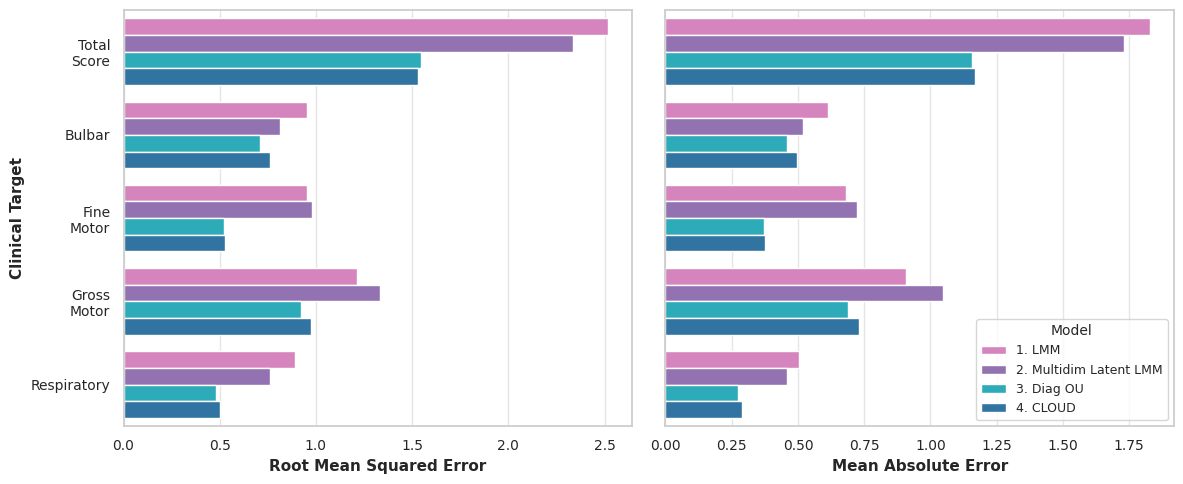

In [3]:
# ==========================================
# 4. VISUALIZATION
# ==========================================
print("Generating Final Publication Visuals in PNG, SVG, and PDF formats...")

import matplotlib.pyplot as plt
import seaborn as sns

# Optional fallback in case save_multiformat is not already defined elsewhere
if 'save_multiformat' not in globals():
    def save_multiformat(filename, dpi=600):
        plt.savefig(f"{filename}.png", dpi=dpi, bbox_inches='tight', facecolor='white')
        plt.savefig(f"{filename}.svg", bbox_inches='tight', facecolor='white')
        plt.savefig(f"{filename}.pdf", bbox_inches='tight', facecolor='white')

# Ensure the multidimensional latent baseline name exists
if 'MODEL2_NAME' not in globals():
    MODEL2_NAME = '2. Multidim Latent LMM'

# White background with grid lines
sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white"
    }
)

# Updated color map for the modified pipeline
model_colors = {
    '1. LMM': '#e377c2',
    MODEL2_NAME: '#9467bd',
    '3. Diag OU': '#17becf',
    '4. CLOUD': '#1f77b4',
}

# Build macro-level dataframe
df_macro_plot = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()

if df_macro_plot.empty:
    print(" -> No macro-level rows found in df_metrics. Skipping Fig_AB_Macro_Metrics.")
else:
    # Rename targets to use line breaks for tighter left margins
    rename_map = {
        'Total Score': 'Total\nScore',
        'Fine_Motor': 'Fine\nMotor',
        'Gross_Motor': 'Gross\nMotor',
        'Bulbar': 'Bulbar',
        'Respiratory': 'Respiratory'
    }

    df_macro_plot['Target_Label'] = df_macro_plot['Target'].astype(str).replace(rename_map)

    target_order = [
        'Total\nScore',
        'Bulbar',
        'Fine\nMotor',
        'Gross\nMotor',
        'Respiratory'
    ]

    df_macro_plot['Target_Label'] = pd.Categorical(
        df_macro_plot['Target_Label'],
        categories=target_order,
        ordered=True
    )

    # Use the pipeline model order when available, but only keep models that exist in df_macro_plot
    if 'mod_order' in globals():
        base_model_order = list(mod_order)
    else:
        base_model_order = [
            '1. LMM',
            MODEL2_NAME,
            '3. Diag OU',
            '4. CLOUD'
        ]

    observed_models = [
        m for m in df_macro_plot['Model'].astype(str).dropna().unique()
        if m != 'nan'
    ]

    present_model_order = [
        m for m in base_model_order
        if m in observed_models
    ]

    # Append any unexpected models that are present but not listed in mod_order
    present_model_order += [
        m for m in observed_models
        if m not in present_model_order
    ]

    # Restrict plot to models that are actually present
    df_macro_plot = df_macro_plot[
        df_macro_plot['Model'].astype(str).isin(present_model_order)
    ].copy()

    df_macro_plot['Model_Label'] = pd.Categorical(
        df_macro_plot['Model'].astype(str),
        categories=present_model_order,
        ordered=True
    )

    # Palette restricted to models present in the figure
    plot_palette = {
        m: model_colors.get(m, '#333333')
        for m in present_model_order
    }

    # Set base font sizes for publication scaling
    plt.rc('axes', titlesize=13, labelsize=11)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=9, title_fontsize=10)

    # Create a 1x2 grid sharing the Y-axis
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12, 5),
        sharey=True
    )

    # ==========================================
    # Panel A: Macro-Level RMSE
    # ==========================================
    sns.barplot(
        data=df_macro_plot,
        y='Target_Label',
        x='RMSE',
        hue='Model_Label',
        palette=plot_palette,
        hue_order=present_model_order,
        ax=axes[0]
    )

    # axes[0].set_title('Macro-Level RMSE', fontweight='bold')
    axes[0].set_xlabel('Root Mean Squared Error', fontweight='bold')
    axes[0].set_ylabel('Clinical Target', fontweight='bold')

    axes[0].grid(axis='x', linestyle='-', alpha=0.5)
    axes[0].set_axisbelow(True)

    legend0 = axes[0].get_legend()
    if legend0 is not None:
        legend0.remove()

    # ==========================================
    # Panel B: Macro-Level MAE
    # ==========================================
    sns.barplot(
        data=df_macro_plot,
        y='Target_Label',
        x='MAE',
        hue='Model_Label',
        palette=plot_palette,
        hue_order=present_model_order,
        ax=axes[1]
    )

    # axes[1].set_title('Macro-Level MAE', fontweight='bold')
    axes[1].set_xlabel('Mean Absolute Error', fontweight='bold')
    axes[1].set_ylabel('')

    axes[1].grid(axis='x', linestyle='-', alpha=0.5)
    axes[1].set_axisbelow(True)

    axes[1].legend(
        title='Model',
        loc='lower right',
        frameon=True
    )

    plt.tight_layout()
    save_multiformat('Fig_AB_Macro_Metrics')

    print(" -> Generated manuscript-ready 'Fig_AB_Macro_Metrics' with combined panels.")

# Optional reset
# plt.rcdefaults()
# sns.reset_defaults()

 -> Successfully loaded 1. LMM
 -> Successfully loaded 2. Multidim Latent LMM
 -> Successfully loaded 3. Diag OU
 -> Successfully loaded 4. CLOUD
 -> Extracted 12 averaged item-to-domain effects for 1. LMM.
 -> Extracted 12 direct beta_t_dyn domain effects for 2. Multidim Latent LMM.
 -> Extracted 12 direct alpha_dyn domain effects for 3. Diag OU.
 -> Extracted 12 direct alpha_dyn domain effects for 4. CLOUD.
 -> Saved direct domain-level forest plotting table: domain_level_covariate_effects_for_forest.csv
 -> No direct domain-level covariate rows found for Sex_Female. Skipping forest plot.
 -> No direct domain-level covariate rows found for Treatment_Active. Skipping forest plot.
 -> No direct domain-level covariate rows found for Age_Base. Skipping forest plot.
 -> Generated domain-level forest plot for Bulbar_Onset.
 -> Generated domain-level forest plot for FVC_Base.
 -> Generated domain-level forest plot for BMI_Base.


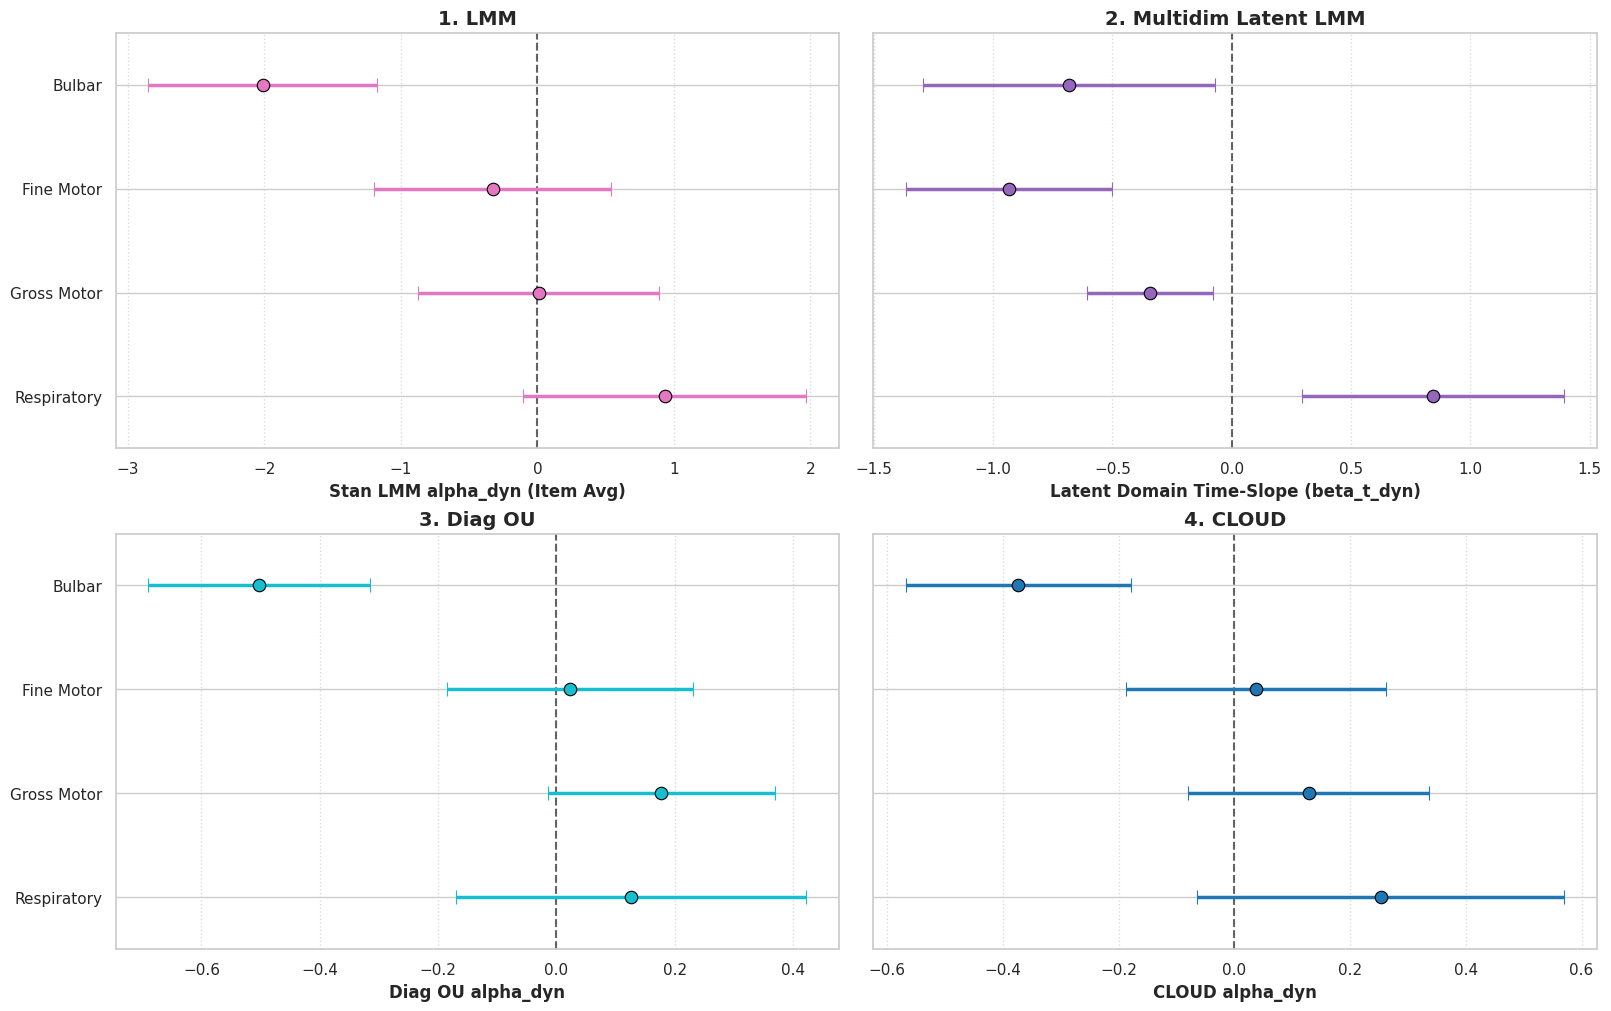

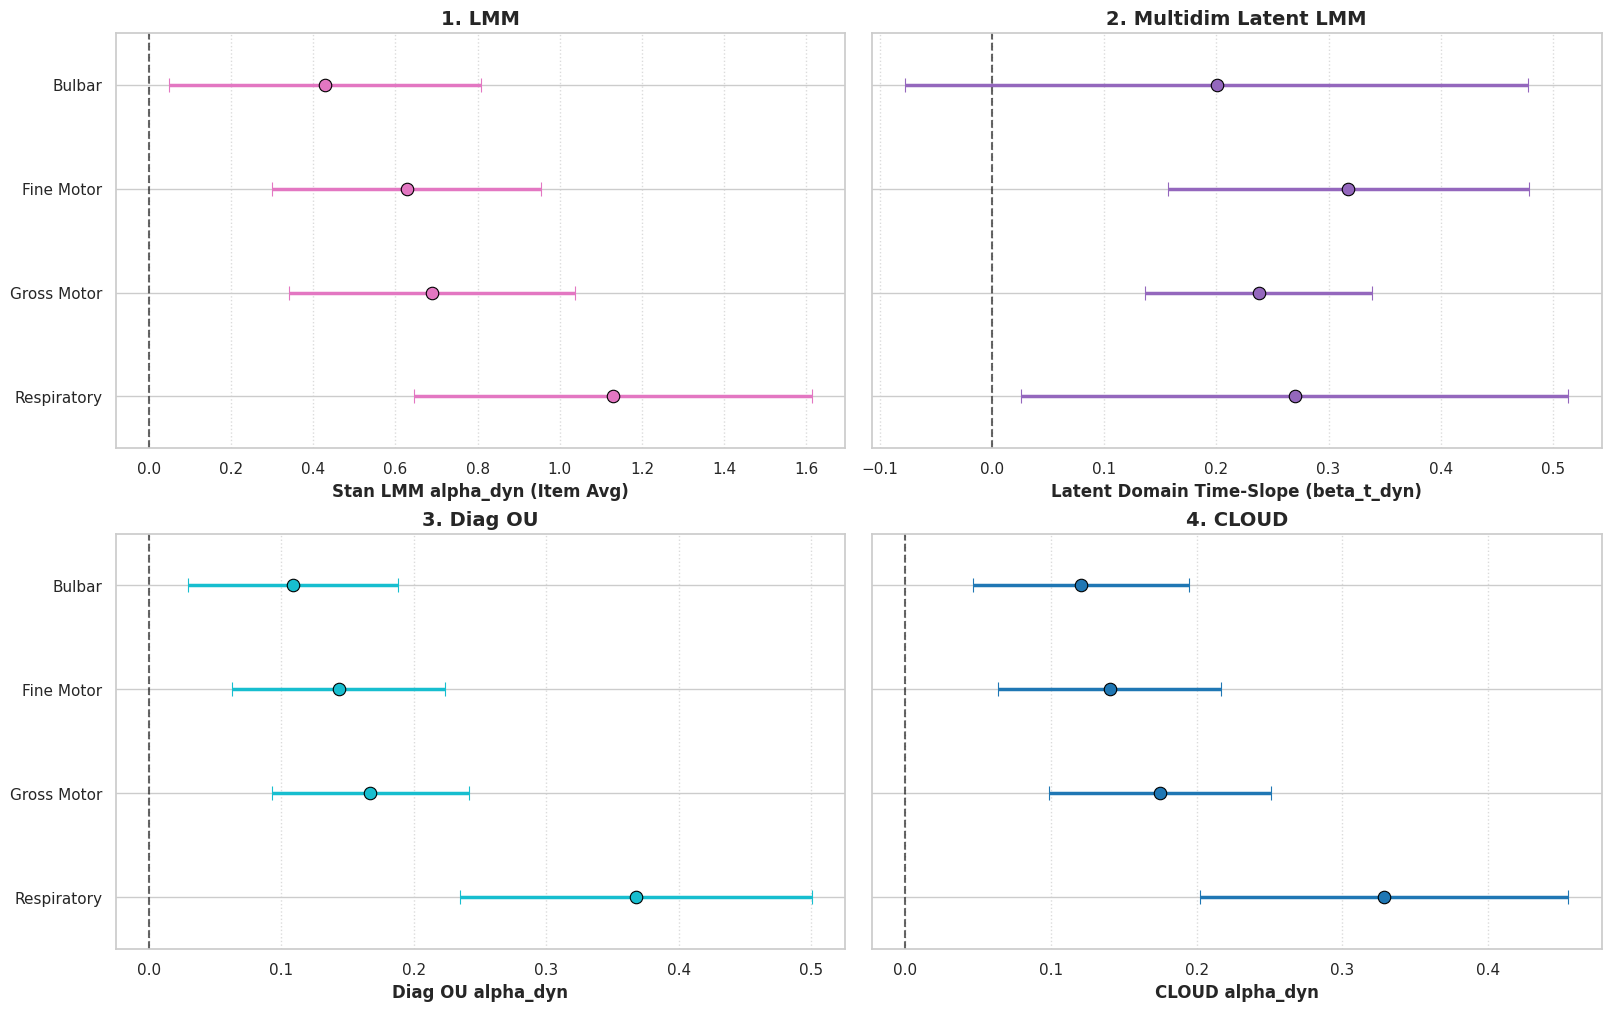

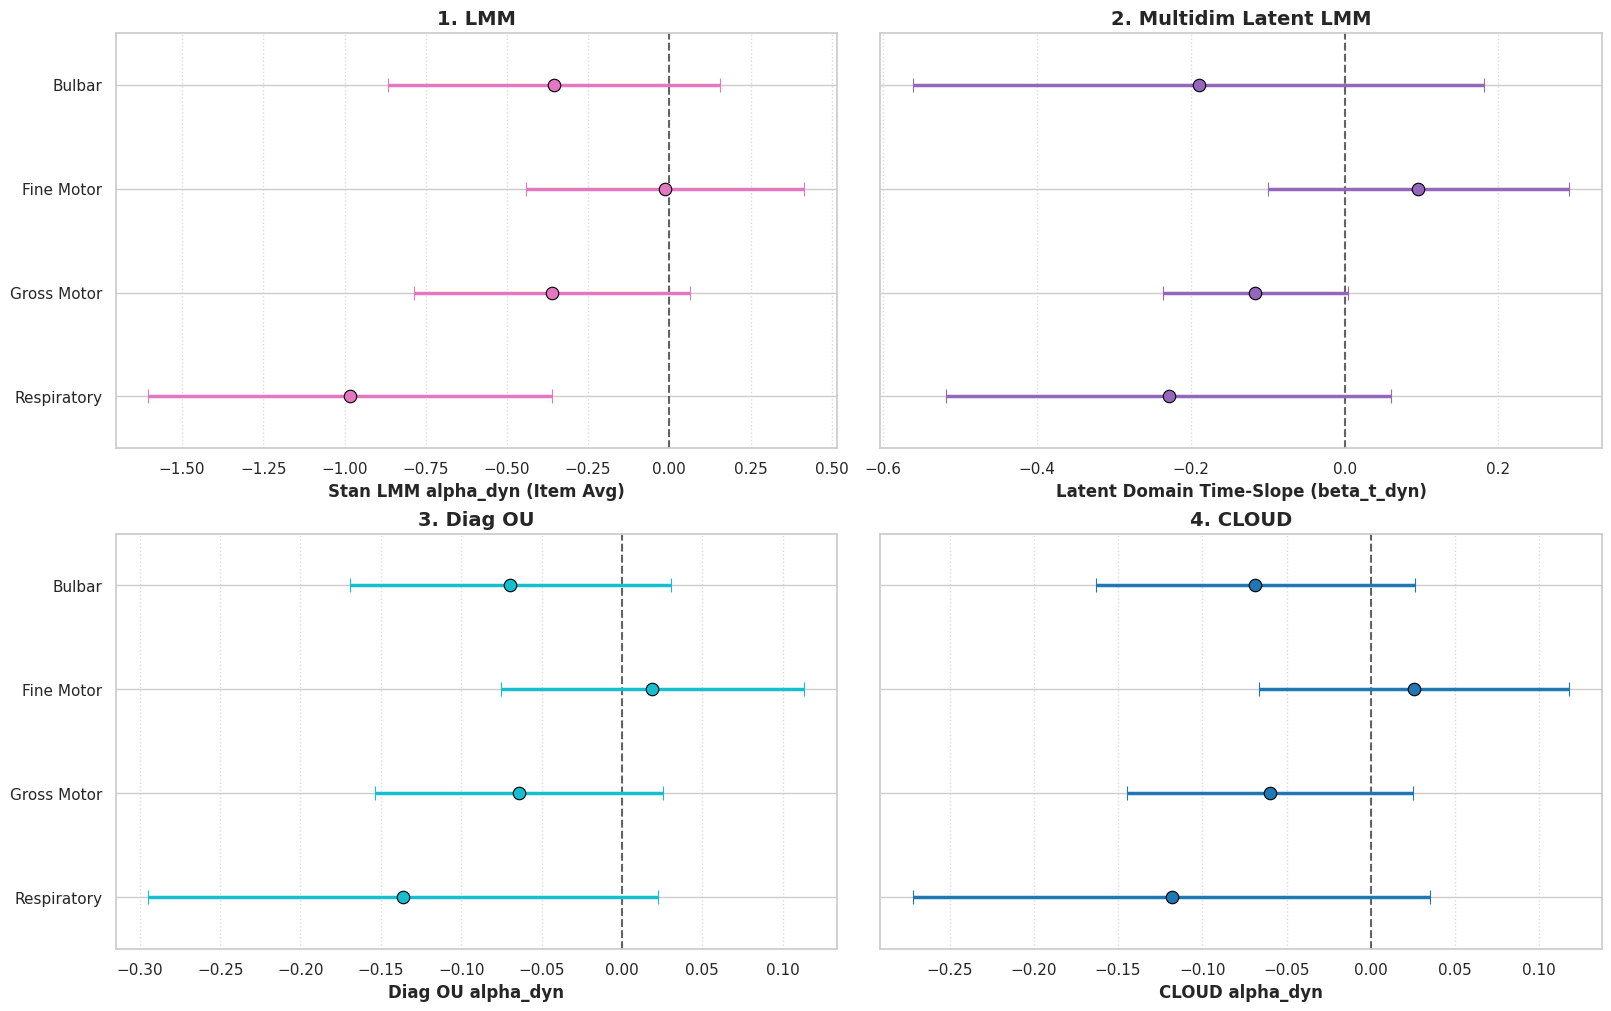

In [5]:
# ==========================================
# Plot D: Domain-Level Forest Plots
# Point Estimate + 95% CI
# 2x2 Layout
#
# IMPORTANT:
# This plot uses direct DOMAIN-LEVEL effects only, extracted strictly from Stan.
#
# - Model 1 LMM:
#     Uses alpha_dyn[item, covariate] from the Stan LMM summary.
#     Averages the 3 item-level estimates & SEs to generate a domain-level proxy.
#
# - Model 2 Multidim Latent LMM:
#     uses beta_t_dyn[domain, covariate] directly from the mltlmm Stan summary.
#
# - Model 3 Diag OU:
#     uses alpha_dyn[domain, covariate] directly from the Diag OU Stan summary.
#
# - Model 4 CLOUD:
#     uses alpha_dyn[domain, covariate] directly from the CLOUD Stan summary.
# ==========================================

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ==========================================
# Configuration
# ==========================================
MODEL2_NAME = '2. Multidim Latent LMM'
diag_ou_model_name = '3. Diag OU'
cloud_model_name = '4. CLOUD'

forest_model_order = [
    '1. LMM',
    MODEL2_NAME,
    diag_ou_model_name,
    cloud_model_name
]

domain_order = [
    'Bulbar',
    'Fine_Motor',
    'Gross_Motor',
    'Respiratory'
]

domain_label_map = {
    'Bulbar': 'Bulbar',
    'Fine_Motor': 'Fine Motor',
    'Gross_Motor': 'Gross Motor',
    'Respiratory': 'Respiratory'
}

model_colors = {
    '1. LMM': '#e377c2',
    MODEL2_NAME: '#9467bd',
    diag_ou_model_name: '#17becf',
    cloud_model_name: '#1f77b4',
}

dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
all_covariates = meas_covariates + dyn_covariates

mcmc_dfs = {}

# Explicit paths for auto-loading
MCMC_PATHS = {
    '1. LMM': "/nobackup/zwu1/gnpc_explor/new_results/results_S1_lmm_run1.csv",
    MODEL2_NAME: "/nobackup/zwu1/gnpc_explor/new_results/results_S1_mltlmm_run1.csv",
    diag_ou_model_name: "../new_results/results_S1_dahlou_ncp_full_diag_run1.csv",
    cloud_model_name: "../new_results/results_S1_dahlou_ncp_full_run1.csv"
}

for name, path in MCMC_PATHS.items():
    try:
        mcmc_dfs[name] = pd.read_csv(path)
        print(f" -> Successfully loaded {name}")
    except Exception as e:
        print(f"[WARNING] Could not load {name} from {path}: {e}")

# ==========================================
# Helper functions
# ==========================================

def safe_num(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan

def infer_summary_se(row):
    for col in ['sd', 'SD', 'StdDev', 'Std.Dev.', 'Std_Error', 'Std.Error', 'SE']:
        if col in row.index and pd.notna(row[col]):
            return safe_num(row[col])

    if '97.5%' in row.index and '2.5%' in row.index and pd.notna(row['97.5%']) and pd.notna(row['2.5%']):
        return safe_num((row['97.5%'] - row['2.5%']) / (2 * 1.96))

    return np.nan

def add_domain_cov_row(rows, model, domain, covariate, est, se, source):
    est = safe_num(est)
    se = safe_num(se)

    if not np.isfinite(est):
        return

    z = est / se if np.isfinite(se) and se != 0 else 0.0

    rows.append({
        'Model': model,
        'Domain': domain,
        'Covariate': covariate,
        'Est': est,
        'SE': se,
        'Z_Score': z,
        'Source': source
    })

def get_forest_xlabel(model, cov):
    if cov in meas_covariates:
        return "No Direct Domain-Level Effect"
    else:
        if model == '1. LMM':
            return "Stan LMM alpha_dyn (Item Avg)"
        elif model == MODEL2_NAME:
            return "Latent Domain Time-Slope (beta_t_dyn)"
        elif model == diag_ou_model_name:
            return "Diag OU alpha_dyn"
        elif model == cloud_model_name:
            return "CLOUD alpha_dyn"
        else:
            return "Estimate"

def extract_stan_domain_effects(model_label, rows, param_name='alpha_dyn'):
    if model_label not in mcmc_dfs or mcmc_dfs[model_label].empty:
        print(f" -> Failed to load MCMC summary to extract {param_name} for {model_label}.")
        return

    df_m = mcmc_dfs[model_label].copy()

    alpha_rows = df_m[
        df_m['Parameter'].astype(str).str.contains(rf'^{param_name}\[', regex=True)
    ].copy()

    if alpha_rows.empty:
        return

    try:
        alpha_rows[['Domain_idx', 'Cov_idx']] = (
            alpha_rows['Parameter'].astype(str).str.extract(r'\[(\d+),(\d+)\]').astype(int)
        )
    except Exception:
        return

    cov_map_dyn = {idx + 1: cov for idx, cov in enumerate(dyn_covariates)}
    n_added = 0

    for _, row in alpha_rows.iterrows():
        dom_idx = int(row['Domain_idx']) - 1
        cov_idx = int(row['Cov_idx'])

        if dom_idx < 0 or dom_idx >= len(domain_order):
            continue
        if cov_idx not in cov_map_dyn:
            continue

        dom = domain_order[dom_idx]
        cov = cov_map_dyn[cov_idx]

        add_domain_cov_row(
            rows,
            model=model_label,
            domain=dom,
            covariate=cov,
            est=row['Estimate'],
            se=infer_summary_se(row),
            source=f'direct_{model_label}_{param_name}'
        )
        n_added += 1

    print(f" -> Extracted {n_added} direct {param_name} domain effects for {model_label}.")

def extract_stan_lmm_averaged_effects(rows):
    model_label = '1. LMM'
    if model_label not in mcmc_dfs or mcmc_dfs[model_label].empty:
        print(f" -> LMM MCMC summary not available for averaging.")
        return

    df_m = mcmc_dfs[model_label].copy()
    alpha_rows = df_m[df_m['Parameter'].astype(str).str.contains(r'^alpha_dyn\[', regex=True)].copy()

    if alpha_rows.empty:
        return

    alpha_rows[['Item_idx', 'Cov_idx']] = (
        alpha_rows['Parameter'].astype(str).str.extract(r'\[(\d+),(\d+)\]').astype(int)
    )

    cov_map_dyn = {idx + 1: cov for idx, cov in enumerate(dyn_covariates)}
    domain_items = {
        'Bulbar': [1, 2, 3],
        'Fine_Motor': [4, 5, 6],
        'Gross_Motor': [7, 8, 9],
        'Respiratory': [10, 11, 12]
    }

    n_added = 0
    for cov_idx, cov in cov_map_dyn.items():
        cov_subset = alpha_rows[alpha_rows['Cov_idx'] == cov_idx]
        for dom, items in domain_items.items():
            dom_rows = cov_subset[cov_subset['Item_idx'].isin(items)]
            
            if not dom_rows.empty:
                # Average the item estimates to get a proxy domain estimate
                avg_est = dom_rows['Estimate'].mean()
                # Average the SEs 
                ses = [infer_summary_se(r) for _, r in dom_rows.iterrows()]
                avg_se = np.nanmean(ses)

                add_domain_cov_row(
                    rows,
                    model=model_label,
                    domain=dom,
                    covariate=cov,
                    est=avg_est,
                    se=avg_se,
                    source='averaged_item_alpha_dyn'
                )
                n_added += 1

    print(f" -> Extracted {n_added} averaged item-to-domain effects for {model_label}.")

def save_multiformat(filename):
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')

# ==========================================
# Build domain-level covariate-effect table
# ==========================================
domain_cov_rows = []

# A. Model 1: Stan LMM (Averaged Item-Level)
extract_stan_lmm_averaged_effects(domain_cov_rows)

# B. Model 2: Multidimensional latent LMM (beta_t_dyn)
extract_stan_domain_effects(MODEL2_NAME, domain_cov_rows, param_name='beta_t_dyn')

# C. Model 3: Diag OU (alpha_dyn)
extract_stan_domain_effects(diag_ou_model_name, domain_cov_rows, param_name='alpha_dyn')

# D. Model 4: CLOUD (alpha_dyn)
extract_stan_domain_effects(cloud_model_name, domain_cov_rows, param_name='alpha_dyn')

# ==========================================
# E. Final plotting table
# ==========================================
df_domain_covs_plot = pd.DataFrame(domain_cov_rows)

if df_domain_covs_plot.empty:
    print(" -> No direct domain-level covariate effects available. Skipping Plot D.")
else:
    df_domain_covs_plot['Model'] = df_domain_covs_plot['Model'].astype(str)

    df_domain_covs_plot['Domain'] = pd.Categorical(
        df_domain_covs_plot['Domain'],
        categories=domain_order,
        ordered=True
    )

    df_domain_covs_plot['Domain_Label'] = (
        df_domain_covs_plot['Domain'].astype(str).replace(domain_label_map)
    )

    df_domain_covs_plot['Domain_Label'] = pd.Categorical(
        df_domain_covs_plot['Domain_Label'],
        categories=[domain_label_map[d] for d in domain_order],
        ordered=True
    )

    df_domain_covs_plot['Model'] = pd.Categorical(
        df_domain_covs_plot['Model'],
        categories=forest_model_order,
        ordered=True
    )

    df_domain_covs_plot = df_domain_covs_plot.sort_values(['Covariate', 'Model', 'Domain'])
    df_domain_covs_plot.to_csv("domain_level_covariate_effects_for_forest.csv", index=False)
    print(" -> Saved direct domain-level forest plotting table: domain_level_covariate_effects_for_forest.csv")

# ==========================================
# Generate one domain-level forest plot per covariate
# ==========================================
if not df_domain_covs_plot.empty:
    sns.set_theme(
        style="whitegrid",
        rc={
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "savefig.facecolor": "white"
        }
    )

    domain_labels = [domain_label_map[d] for d in domain_order]
    domain_to_y = {label: len(domain_labels) - 1 - i for i, label in enumerate(domain_labels)}

    ytick_positions = [domain_to_y[label] for label in domain_labels]
    ytick_labels = domain_labels

    for cov in all_covariates:
        subset = df_domain_covs_plot[df_domain_covs_plot['Covariate'].astype(str) == cov].copy()

        if subset.empty:
            print(f" -> No direct domain-level covariate rows found for {cov}. Skipping forest plot.")
            continue

        subset['Model_Str'] = subset['Model'].astype(str)
        subset['Domain_Label_Str'] = subset['Domain_Label'].astype(str)
        subset['Est'] = pd.to_numeric(subset['Est'], errors='coerce')
        subset['SE'] = pd.to_numeric(subset['SE'], errors='coerce')

        subset = subset[subset['Model_Str'].isin(forest_model_order)].copy()

        fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True, constrained_layout=True)
        axes_flat = axes.flatten()

        for i, model in enumerate(forest_model_order):
            ax = axes_flat[i]
            mod_data = subset[subset['Model_Str'] == model].copy()
            mod_data['y_pos'] = mod_data['Domain_Label_Str'].map(domain_to_y)
            mod_data = mod_data.dropna(subset=['y_pos', 'Est']).copy()
            mod_data['y_pos'] = mod_data['y_pos'].astype(float)
            mod_data['CI_Margin'] = 1.96 * mod_data['SE'].abs()
            mod_data = mod_data.sort_values('y_pos')

            ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

            if not mod_data.empty:
                c_val = model_colors.get(model, '#333333')

                with_ci = mod_data[mod_data['CI_Margin'].notna() & np.isfinite(mod_data['CI_Margin'])]
                if not with_ci.empty:
                    ax.errorbar(
                        x=with_ci['Est'].values, y=with_ci['y_pos'].values,
                        xerr=with_ci['CI_Margin'].values,
                        fmt='o', color=c_val, ecolor=c_val, elinewidth=2.5,
                        capsize=5, capthick=2, markersize=9,
                        markeredgecolor='black', markeredgewidth=0.8, zorder=3
                    )

                no_ci = mod_data[mod_data['CI_Margin'].isna() | ~np.isfinite(mod_data['CI_Margin'])]
                if not no_ci.empty:
                    ax.scatter(
                        no_ci['Est'].values, no_ci['y_pos'].values,
                        s=90, color=c_val, edgecolor='black', linewidth=0.8, zorder=3
                    )
            else:
                ax.text(
                    0.5, 0.5, "No direct\ndomain-level\nestimate",
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=12, color='gray', fontweight='bold'
                )

            ax.set_title(model, fontweight='bold', fontsize=14)
            ax.set_xlabel(get_forest_xlabel(model, cov), fontweight='bold', fontsize=12)
            ax.grid(True, axis='x', linestyle=':', alpha=0.7, zorder=0)
            ax.set_axisbelow(True)
            ax.set_yticks(ytick_positions)

            if i % 2 == 0:
                ax.set_yticklabels(ytick_labels, fontsize=11)
            else:
                ax.tick_params(axis='y', labelleft=False)

            ax.set_ylim(-0.5, len(domain_labels) - 0.5)

        save_multiformat(f"Fig_D_Domain_Forest_{cov}")
        print(f" -> Generated domain-level forest plot for {cov}.")

=== STARTING STATSMODELS VS STAN LMM COMPARISON ===

Fitting Frequentist LMMs (statsmodels)...
Extracting Bayesian LMMs (Stan)...

PREDICTIVE METRICS (ITEM LEVEL)
                               RMSE               MAE               MSE              MASE            
Engine                         Stan Statsmodels  Stan Statsmodels  Stan Statsmodels  Stan Statsmodels
Item                                                                                                 
Q1_Speech                     0.450       0.375 0.273       0.246 0.203       0.140 1.342       1.211
Q2_Salivation                 0.449       0.418 0.266       0.261 0.201       0.175 1.045       1.026
Q3_Swallowing                 0.425       0.393 0.239       0.241 0.180       0.154 1.218       1.228
Q4_Handwriting                0.477       0.441 0.296       0.309 0.228       0.194 1.051       1.098
Q5_Cutting                    0.438       0.437 0.296       0.315 0.192       0.191 0.993       1.054
Q6_Dressing_and_Hygie

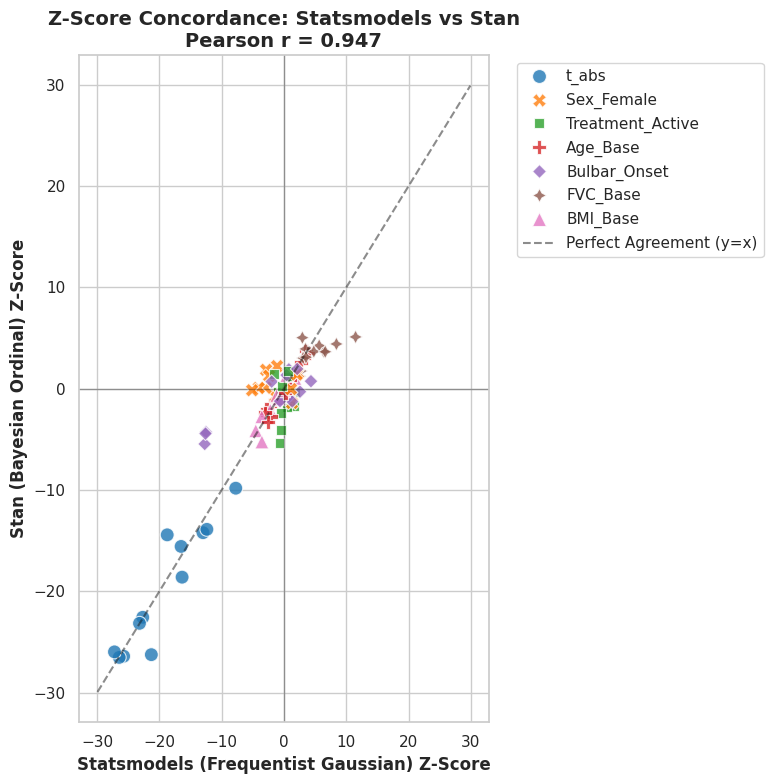

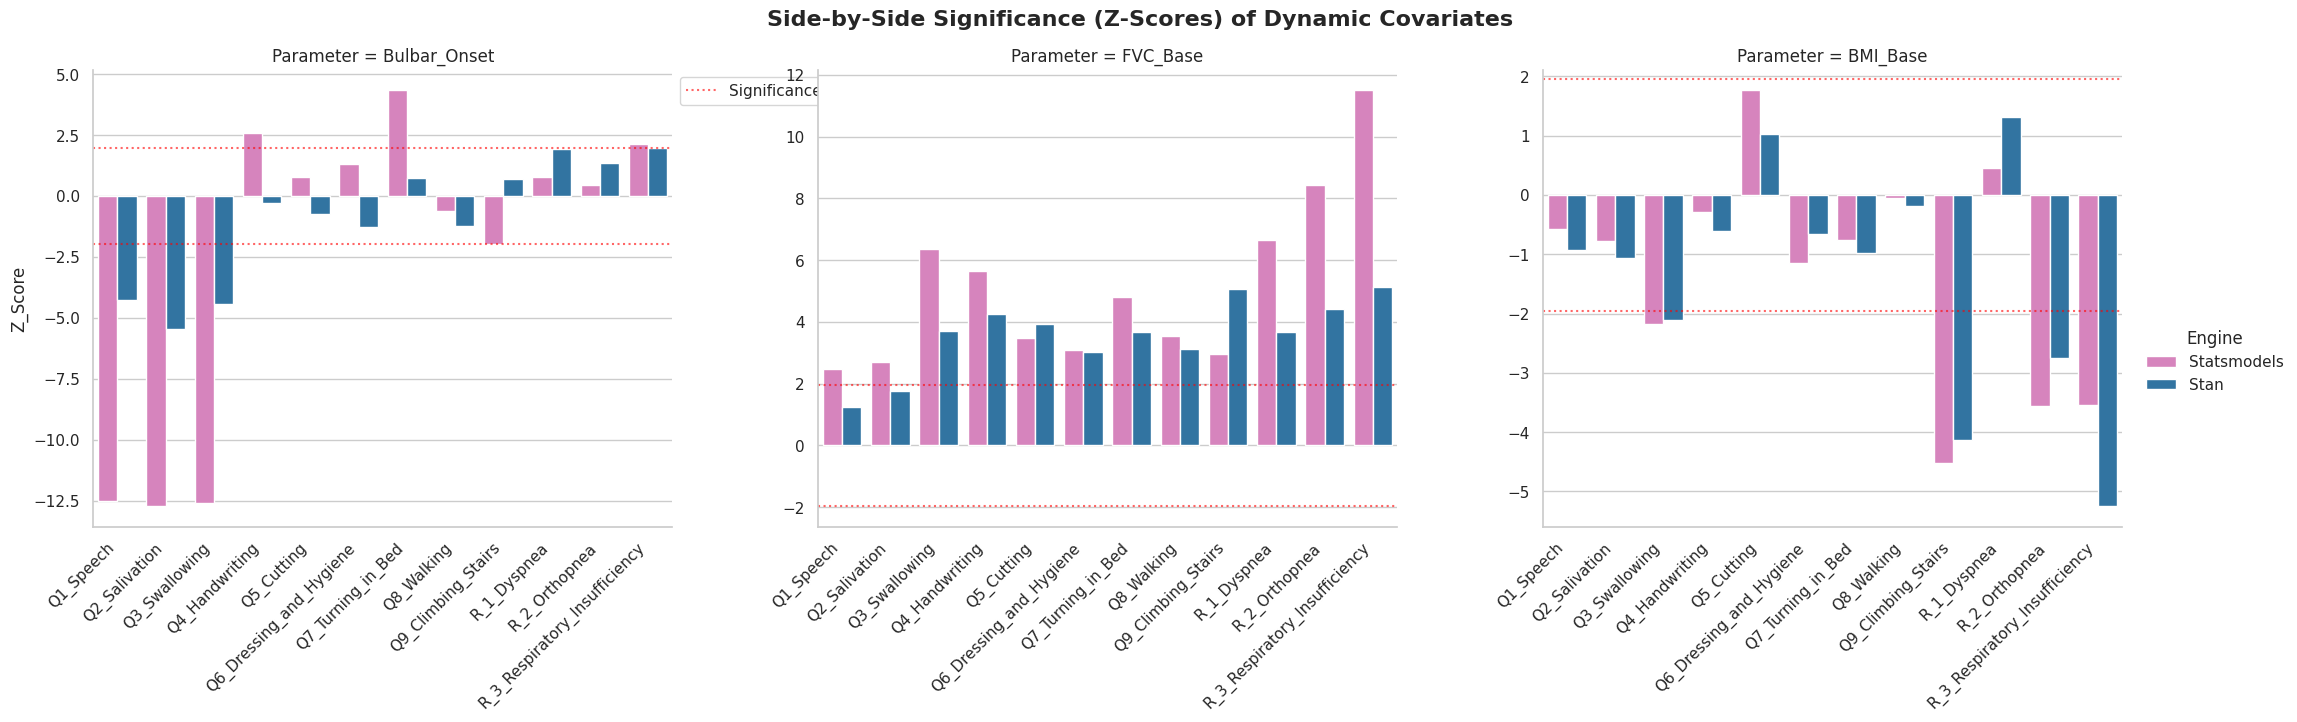

In [5]:
# ==========================================
# LMM ENGINE COMPARISON: Statsmodels vs Stan
# Z-Score Concordance, Predictive Metrics (MSE/MASE), & Visualizations
# ==========================================

import re
import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

print("=== STARTING STATSMODELS VS STAN LMM COMPARISON ===")

# ==========================================
# 1. CONFIGURATION & FEATURE ENGINEERING
# ==========================================
DATA_FILE = "proact_preprocessed_S1.csv"
STAN_FILE = "/nobackup/zwu1/gnpc_explor/new_results/results_S1_lmm_run1.csv"

meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
items = [
    'Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing', 'Q4_Handwriting',
    'Q5_Cutting', 'Q6_Dressing_and_Hygiene', 'Q7_Turning_in_Bed',
    'Q8_Walking', 'Q9_Climbing_Stairs', 'R_1_Dyspnea',
    'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency'
]

try:
    df = pd.read_csv(DATA_FILE)
except Exception as e:
    print(f"Failed to load data: {e}")
    exit()

# Time Scale & Interactions
df['t_abs'] = df['ALSFRS_Delta'] / 365.25
for c in dyn_covariates:
    df[f'{c}_x_t_abs'] = df[c] * df['t_abs']

# Lags for MASE (Naive Baseline)
df = df.sort_values(by=['subject_id', 'ALSFRS_Delta']).reset_index(drop=True)
for item in items:
    df[f'{item}_Lag'] = df.groupby('subject_id')[item].shift(1)

# Storage for results
sm_params, stan_params = [], []
metrics_results = []

# ==========================================
# METRIC HELPER
# ==========================================
def compute_metrics(engine, item, actual, expected, actual_lag):
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)
    actual_lag = np.asarray(actual_lag, dtype=float)

    mask = ~np.isnan(expected) & ~np.isnan(actual) & ~np.isnan(actual_lag)
    if not np.any(mask): return

    act_m, exp_m, lag_m = actual[mask], expected[mask], actual_lag[mask]

    mse = mean_squared_error(act_m, exp_m)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(act_m, exp_m)
    
    naive_mae = mean_absolute_error(act_m, lag_m)
    mase = mae / naive_mae if naive_mae > 1e-6 else np.nan

    metrics_results.append({
        'Engine': engine,
        'Item': item,
        'RMSE': rmse,
        'MAE': mae,
        'MSE': mse,
        'MASE': mase
    })

# ==========================================
# 2. RUN FREQUENTIST LMM (STATSMODELS)
# ==========================================
print("\nFitting Frequentist LMMs (statsmodels)...")

meas_str = " + ".join(meas_covariates)
dyn_time_str = " + ".join([f"{c}_x_t_abs" for c in dyn_covariates])
formula_base = f"t_abs + {meas_str} + {dyn_time_str}"

for item in items:
    req_cols = [item, f'{item}_Lag', 't_abs', 'subject_id'] + meas_covariates + [f"{c}_x_t_abs" for c in dyn_covariates]
    df_clean = df.dropna(subset=req_cols).copy()
    if df_clean.empty: continue
        
    try:
        model = smf.mixedlm(f"{item} ~ {formula_base}", df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
        
        # Predictive Metrics
        fitted = np.clip(np.asarray(model.fittedvalues, dtype=float), 0, 4)
        compute_metrics('Statsmodels', item, df_clean[item].values, fitted, df_clean[f'{item}_Lag'].values)

        # Z-Scores
        for param in model.params.index:
            if param in ['Group Var', 'Intercept']: continue
            est = model.params[param]
            se = model.bse[param]
            sm_params.append({
                'Item': item,
                'Parameter': param.replace('_x_t_abs', ''),
                'SM_Est': est,
                'SM_SE': se,
                'SM_Z': est / se if se != 0 else 0
            })
    except Exception as e:
        pass

df_sm = pd.DataFrame(sm_params)

# ==========================================
# 3. EXTRACT BAYESIAN LMM (STAN)
# ==========================================
print("Extracting Bayesian LMMs (Stan)...")
df_stan_raw = pd.read_csv(STAN_FILE)

def ext_stan(df_m, param, shape):
    out = np.zeros(shape)
    subset = df_m[df_m['Parameter'].astype(str).str.contains(rf"^{param}\[", regex=True)]
    for _, r in subset.iterrows():
        try:
            idx = [int(i) - 1 for i in re.search(r'\[(.*?)\]', str(r['Parameter'])).group(1).split(',')]
            if len(idx) == 1: out[idx[0]] = r['Estimate']
            elif len(idx) == 2: out[idx[0], idx[1]] = r['Estimate']
        except Exception: pass
    return out

def get_stan_se(row):
    for col in ['sd', 'StdDev']:
        if col in row and pd.notna(row[col]): return row[col]
    if '97.5%' in row and '2.5%' in row:
        return (row['97.5%'] - row['2.5%']) / (2 * 1.96)
    return np.nan

# Extract Params for Predictions
sub_map = {sub: i for i, sub in enumerate(df['subject_id'].unique())}
ID = df['subject_id'].map(sub_map).values
X_m = df[meas_covariates].fillna(0).values
X_d = df[dyn_covariates].fillna(0).values
t_abs = df['t_abs'].values

theta = ext_stan(df_stan_raw, 'theta', (12, 4))
beta = ext_stan(df_stan_raw, 'beta', (12, 3))
alpha_0 = ext_stan(df_stan_raw, 'alpha_0', (12,))
alpha_dyn = ext_stan(df_stan_raw, 'alpha_dyn', (12, 3))
U0 = ext_stan(df_stan_raw, 'U0', (len(sub_map), 12))

exp_sc = np.full((len(df), 12), np.nan)

for i in range(len(df)):
    for k in range(12):
        eta = np.dot(X_m[i, :], beta[k]) + (alpha_0[k] + np.dot(X_d[i, :], alpha_dyn[k])) * t_abs[i] + U0[ID[i], k]
        p = [expit(1.0 * (eta - th)) for th in theta[k]]
        exp_sc[i, k] = (1.0 - p[0])*0 + (p[0] - p[1])*1 + (p[1] - p[2])*2 + (p[2] - p[3])*3 + p[3]*4

# Compute Stan Metrics
for k, item in enumerate(items):
    compute_metrics('Stan', item, df[item].values, exp_sc[:, k], df[f'{item}_Lag'].values)

# Extract Z-Scores
param_map = {'alpha_0': 't_abs', 'beta': meas_covariates, 'alpha_dyn': dyn_covariates}
for _, row in df_stan_raw.iterrows():
    match = re.search(r'^([a-z_0-9]+)\[(\d+)(?:,(\d+))?\]', str(row['Parameter']))
    if not match: continue
    base_param = match.group(1)
    k_idx = int(match.group(2)) - 1
    if k_idx >= 12 or base_param not in param_map: continue
    
    human_param = 't_abs' if base_param == 'alpha_0' else param_map[base_param][int(match.group(3)) - 1]
    se = get_stan_se(row)
    stan_params.append({
        'Item': items[k_idx],
        'Parameter': human_param,
        'Stan_Est': row['Estimate'],
        'Stan_SE': se,
        'Stan_Z': row['Estimate'] / se if se and se != 0 else 0
    })

df_stan = pd.DataFrame(stan_params)

# ==========================================
# 4. QUANTITATIVE PRINTOUTS
# ==========================================
print("\n" + "="*80)
print("PREDICTIVE METRICS (ITEM LEVEL)")
print("="*80)
df_metrics = pd.DataFrame(metrics_results)
df_metrics_pivot = df_metrics.pivot(index='Item', columns='Engine', values=['RMSE', 'MAE', 'MSE', 'MASE'])
print(df_metrics_pivot.to_string(float_format="{:.3f}".format))

df_compare = pd.merge(df_sm, df_stan, on=['Item', 'Parameter'], how='inner')
df_compare['Z_Diff_Abs'] = (df_compare['SM_Z'] - df_compare['Stan_Z']).abs()

print("\n" + "="*80)
print("QUANTITATIVE COMPARISON: Z-SCORES (SM vs STAN)")
print("="*80)
df_print = df_compare[['Item', 'Parameter', 'SM_Z', 'Stan_Z', 'Z_Diff_Abs']].copy()
df_print['SM_Z'] = df_print['SM_Z'].apply(lambda x: f"{x:8.2f}")
df_print['Stan_Z'] = df_print['Stan_Z'].apply(lambda x: f"{x:8.2f}")
df_print['Z_Diff_Abs'] = df_print['Z_Diff_Abs'].apply(lambda x: f"{x:8.2f}")

print(df_print.sort_values(by='Stan_Z', key=lambda x: x.astype(float).abs(), ascending=False).head(15).to_string(index=False))

corr = df_compare['SM_Z'].corr(df_compare['Stan_Z'])
print(f"\nAggregate Z-Score Agreement (Pearson Correlation): r = {corr:.4f}")

# ==========================================
# 5. VISUALIZATION
# ==========================================
print("\nGenerating Visualizations...")
sns.set_theme(style="whitegrid")

# --- Plot 1: Scatter ---
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_compare, x='SM_Z', y='Stan_Z', hue='Parameter', style='Parameter', s=100, alpha=0.8, palette="tab10")
limit = max(df_compare['SM_Z'].abs().max(), df_compare['Stan_Z'].abs().max()) * 1.1
plt.plot([-limit, limit], [-limit, limit], 'k--', lw=1.5, alpha=0.5, label='Perfect Agreement (y=x)')
plt.axhline(0, color='black', lw=1, alpha=0.3)
plt.axvline(0, color='black', lw=1, alpha=0.3)
plt.title(f"Z-Score Concordance: Statsmodels vs Stan\nPearson r = {corr:.3f}", fontweight='bold', fontsize=14)
plt.xlabel("Statsmodels (Frequentist Gaussian) Z-Score", fontweight='bold')
plt.ylabel("Stan (Bayesian Ordinal) Z-Score", fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("Fig_Compare_Z_Scatter.png", dpi=300)
# plt.close()

# --- Plot 2: Forest / Barplot ---
plot_params = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
df_melt = df_compare[df_compare['Parameter'].isin(plot_params)].melt(
    id_vars=['Item', 'Parameter'], value_vars=['SM_Z', 'Stan_Z'], var_name='Engine', value_name='Z_Score'
)
df_melt['Engine'] = df_melt['Engine'].replace({'SM_Z': 'Statsmodels', 'Stan_Z': 'Stan'})

g = sns.catplot(
    data=df_melt, kind='bar', x='Item', y='Z_Score', hue='Engine', col='Parameter', 
    palette={'Statsmodels': '#e377c2', 'Stan': '#1f77b4'}, sharey=False, height=6, aspect=1.2
)

for ax in g.axes.flatten():
    ax.axhline(1.96, color='red', linestyle=':', alpha=0.6, label='Significance (|Z| > 1.96)')
    ax.axhline(-1.96, color='red', linestyle=':', alpha=0.6)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel("")

handles, labels = g.axes.flatten()[0].get_legend_handles_labels()
if handles: g.axes.flatten()[0].legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 1))

g.figure.suptitle("Side-by-Side Significance (Z-Scores) of Dynamic Covariates", fontweight='bold', fontsize=16)
g.figure.subplots_adjust(top=0.88)
plt.savefig("Fig_Compare_Forest_Z.png", dpi=300, bbox_inches='tight')
# plt.close()

print("✅ Visualizations saved: 'Fig_Compare_Z_Scatter.png' and 'Fig_Compare_Forest_Z.png'")
print("=== COMPARISON COMPLETE ===")

=== STARTING STATSMODELS VS STAN LMM COMPARISON ===

Fitting frequentist Gaussian random-intercept LMMs (statsmodels)...
Statsmodels fixed-effects RHS: t_abs + Sex_Female + Treatment_Active + Age_Base + Bulbar_Onset_x_t_abs + FVC_Base_x_t_abs + BMI_Base_x_t_abs

Extracting Bayesian ordinal LMM summaries from Stan...

FIT STATUS: STATSMODELS
                         Item                                                                    Status Optimizer Converged  N_Fit
                    Q1_Speech                                                                       fit     lbfgs      True 4336.0
                Q2_Salivation                                                                       fit     lbfgs      True 4336.0
                Q3_Swallowing                                                                       fit     lbfgs      True 4336.0
               Q4_Handwriting                                                                       fit     lbfgs      True 4336.0
  

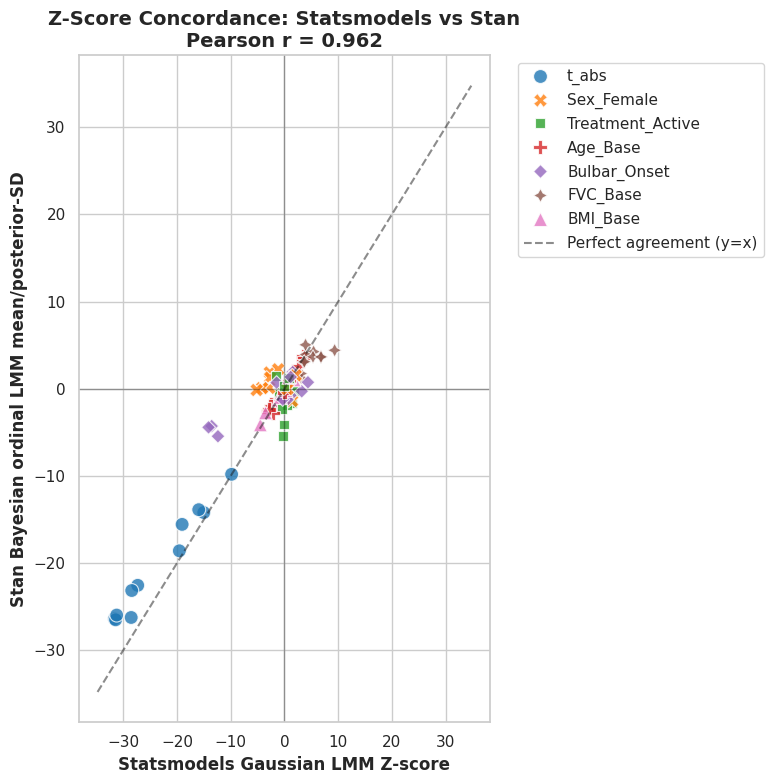

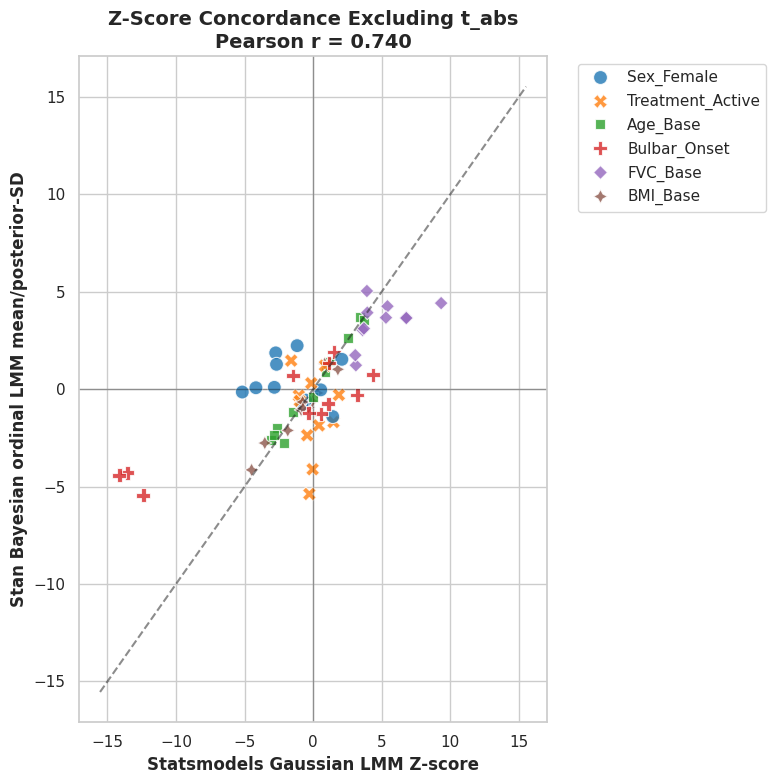

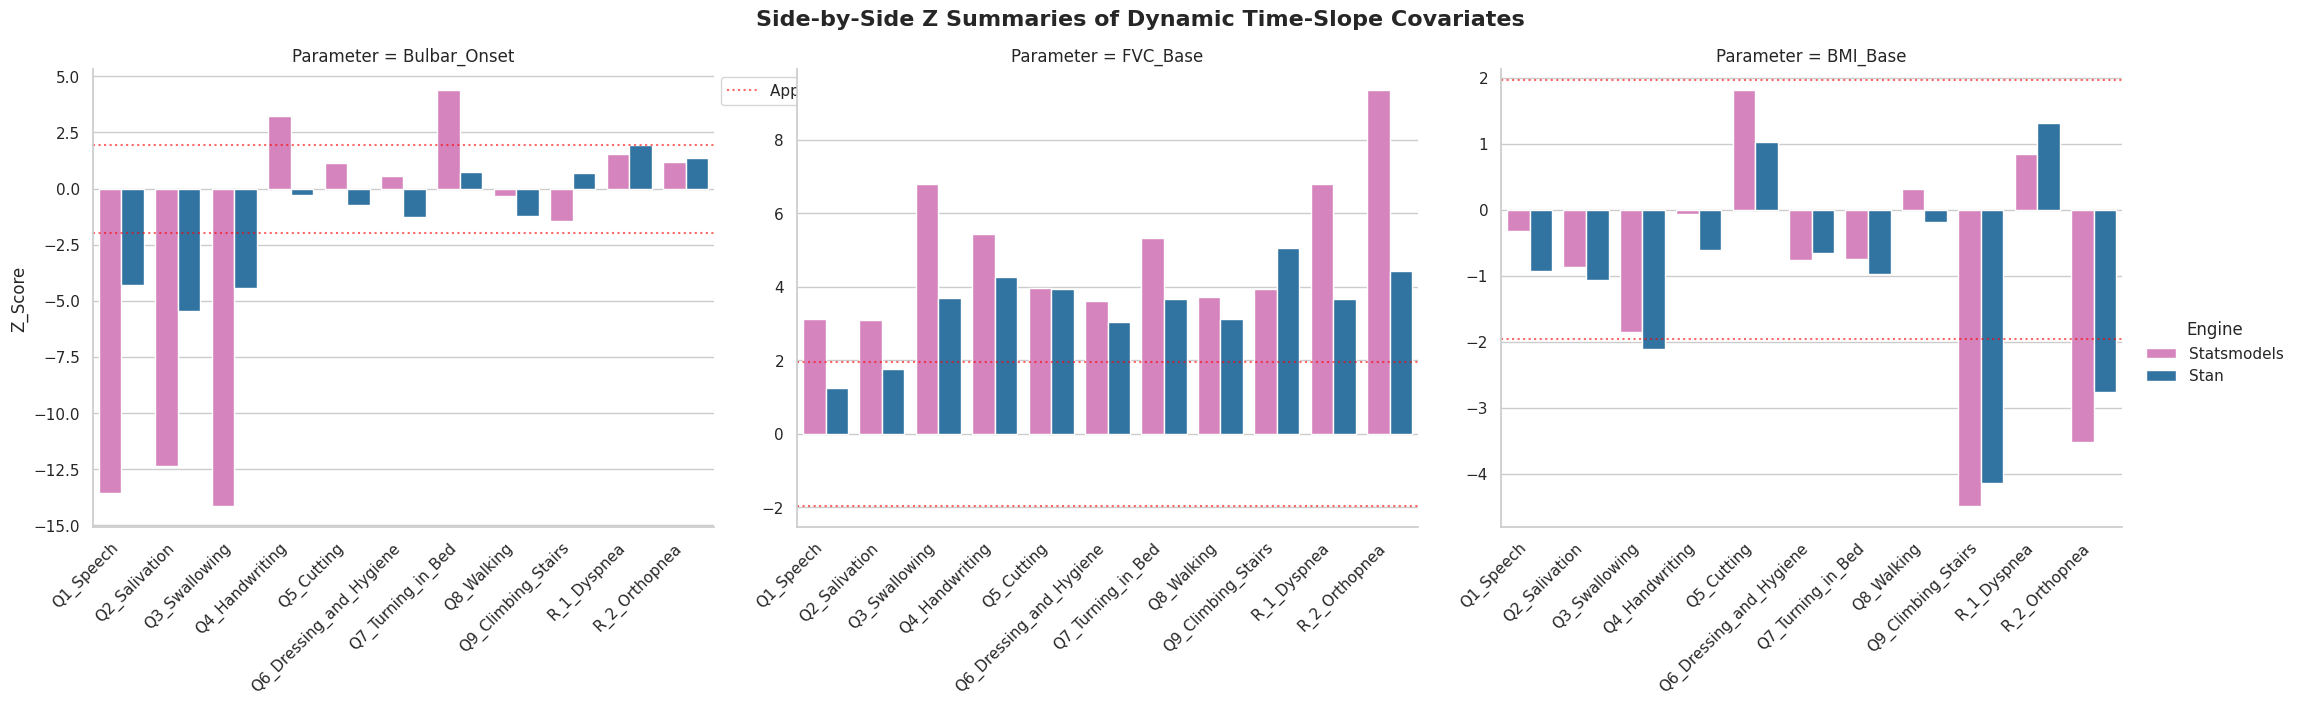

In [7]:
# ==========================================
# LMM ENGINE COMPARISON: Statsmodels vs Stan
# Revised: matched formulas, fairer metrics, Stan ordinal expected scores,
# posterior-direction probabilities, and extra diagnostics.
# ==========================================

import re
import warnings
from typing import Dict, Iterable, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

print("=== STARTING STATSMODELS VS STAN LMM COMPARISON ===")

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_FILE = "proact_preprocessed_S1.csv"
STAN_FILE = "/nobackup/zwu1/gnpc_explor/new_results/results_S1_lmm_run1.csv"

meas_covariates = ["Sex_Female", "Treatment_Active", "Age_Base"]
dyn_covariates = ["Bulbar_Onset", "FVC_Base", "BMI_Base"]
items = [
    "Q1_Speech", "Q2_Salivation", "Q3_Swallowing", "Q4_Handwriting",
    "Q5_Cutting", "Q6_Dressing_and_Hygiene", "Q7_Turning_in_Bed",
    "Q8_Walking", "Q9_Climbing_Stairs", "R_1_Dyspnea",
    "R_2_Orthopnea", "R_3_Respiratory_Insufficiency"
]

# ALSFRS item scores are usually 0,1,2,3,4. Your Stan model uses categories 1..5,
# so the expected Stan score below is transformed back to 0..4 via these levels.
# If your CSV item columns are already 1..5, change this to np.arange(1, 6).
OBSERVED_SCORE_LEVELS = np.arange(0, 5, dtype=float)
SCORE_MIN = float(OBSERVED_SCORE_LEVELS.min())
SCORE_MAX = float(OBSERVED_SCORE_LEVELS.max())

# Must match the subject ordering used when the Stan data list was created.
# Common options are "appearance" for pd.unique order or "sorted" for sorted IDs.
SUBJECT_ORDER_MODE = "appearance"

# "conditional" includes subject random intercepts for in-sample predictions.
# "marginal" uses fixed effects only. Conditional is closest to model.fittedvalues.
PREDICTION_MODE = "conditional"

MAKE_PLOTS = True
SIGMA_Z = 1.96
EPS = 1e-12

# ==========================================
# 2. HELPERS
# ==========================================
def require_columns(df: pd.DataFrame, columns: Sequence[str], label: str) -> None:
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns for {label}: {missing}")


def make_subject_map(subjects: Iterable, mode: str = "appearance") -> Dict:
    vals = pd.Series(subjects).dropna()
    if mode == "sorted":
        ordered = sorted(vals.unique())
    elif mode == "appearance":
        ordered = list(pd.unique(vals))
    else:
        raise ValueError("SUBJECT_ORDER_MODE must be either 'appearance' or 'sorted'.")
    return {sub: i for i, sub in enumerate(ordered)}


def compute_metrics(
    engine: str,
    item: str,
    actual: Sequence[float],
    expected: Sequence[float],
    actual_lag: Sequence[float],
    metrics_results: list,
    prediction_mode: str = PREDICTION_MODE,
) -> None:
    """Compute item-level metrics on rows with actual, prediction, and lag available.

    The lag is used only to define the naive MASE denominator. It should not be
    part of the model-fitting dropna subset.
    """
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)
    actual_lag = np.asarray(actual_lag, dtype=float)

    mask = np.isfinite(actual) & np.isfinite(expected) & np.isfinite(actual_lag)
    n_eval = int(mask.sum())
    if n_eval == 0:
        return

    act_m = actual[mask]
    exp_m = expected[mask]
    lag_m = actual_lag[mask]

    mse = mean_squared_error(act_m, exp_m)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(act_m, exp_m)
    naive_mae = mean_absolute_error(act_m, lag_m)
    mase = mae / naive_mae if naive_mae > EPS else np.nan
    bias = float(np.mean(exp_m - act_m))

    metrics_results.append({
        "Engine": engine,
        "Prediction_Mode": prediction_mode,
        "Item": item,
        "N_Eval": n_eval,
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "Naive_MAE": naive_mae,
        "MASE": mase,
        "Bias_PredMinusObs": bias,
    })


def find_estimate_column(df: pd.DataFrame) -> str:
    for col in ["Estimate", "Mean", "mean", "median", "Median"]:
        if col in df.columns:
            return col
    raise ValueError("Could not find an estimate column in the Stan summary CSV.")


def get_stan_se(row: pd.Series) -> float:
    """Return posterior SD from common Stan-summary column names.

    Falls back to an approximate SD from a 95% interval if necessary.
    """
    for col in ["sd", "SD", "StdDev", "Std.Dev.", "Est.Error", "Std.Error"]:
        if col in row.index and pd.notna(row[col]):
            return float(row[col])

    # Common interval column names. Add more here if your summary uses different names.
    interval_pairs = [
        ("2.5%", "97.5%"),
        ("q2.5", "q97.5"),
        ("Q2.5", "Q97.5"),
        ("5%", "95%"),
    ]
    for lo_col, hi_col in interval_pairs:
        if lo_col in row.index and hi_col in row.index and pd.notna(row[lo_col]) and pd.notna(row[hi_col]):
            # If it is a 90% interval, this denominator is approximate; for 95% it is exact under normality.
            denom = 2 * SIGMA_Z if (lo_col, hi_col) != ("5%", "95%") else 2 * 1.6448536269514722
            return float(row[hi_col] - row[lo_col]) / denom

    return np.nan


def parse_stan_indices(param_name: str, base_param: str) -> Optional[Tuple[int, ...]]:
    m = re.match(rf"^{re.escape(base_param)}\[(.*?)\]$", str(param_name))
    if not m:
        return None
    try:
        return tuple(int(x.strip()) - 1 for x in m.group(1).split(","))
    except Exception:
        return None


def extract_stan_array(
    df_summary: pd.DataFrame,
    base_param: str,
    shape: Tuple[int, ...],
    estimate_col: str,
    fill_value: float = np.nan,
) -> np.ndarray:
    """Extract arrays named like beta[1,2], alpha_0[3], theta[4,1]."""
    out = np.full(shape, fill_value, dtype=float)
    n_found = 0

    for _, row in df_summary.iterrows():
        idx = parse_stan_indices(str(row["Parameter"]), base_param)
        if idx is None or len(idx) != len(shape):
            continue
        if any(idx[d] < 0 or idx[d] >= shape[d] for d in range(len(shape))):
            continue
        if pd.notna(row[estimate_col]):
            out[idx] = float(row[estimate_col])
            n_found += 1

    expected_n = int(np.prod(shape))
    if n_found != expected_n or np.isnan(out).any():
        print(
            f"WARNING: extracted {n_found}/{expected_n} values for {base_param}. "
            "Missing values will make some Stan predictions NaN."
        )
    return out


def ordered_logistic_probs_0to4(eta: float, theta_vec: Sequence[float]) -> np.ndarray:
    """Category probabilities on the observed 0..4 score scale.

    Stan ordered_logistic uses five categories 1..5. If the original observed item
    scale is 0..4, category 1 maps to score 0, ..., category 5 maps to score 4.

    P(Y <= c) = inv_logit(theta[c] - eta), equivalently
    P(Y > c) = inv_logit(eta - theta[c]).
    """
    theta_vec = np.asarray(theta_vec, dtype=float)
    if not np.isfinite(eta) or np.any(~np.isfinite(theta_vec)):
        return np.full(5, np.nan)

    surv = expit(eta - theta_vec)  # P(category > cutpoint c)
    probs = np.empty(5, dtype=float)
    probs[0] = 1.0 - surv[0]
    probs[1] = surv[0] - surv[1]
    probs[2] = surv[1] - surv[2]
    probs[3] = surv[2] - surv[3]
    probs[4] = surv[3]

    # Rounding the posterior mean cutpoints can cause tiny negative values.
    probs = np.clip(probs, 0.0, 1.0)
    total = probs.sum()
    if total <= EPS:
        return np.full(5, np.nan)
    return probs / total


def ordered_logistic_expected_score(eta: float, theta_vec: Sequence[float]) -> float:
    probs = ordered_logistic_probs_0to4(eta, theta_vec)
    if np.any(~np.isfinite(probs)):
        return np.nan
    return float(np.dot(probs, OBSERVED_SCORE_LEVELS))


def fit_mixedlm_with_fallback(formula: str, data: pd.DataFrame, group_col: str):
    """Fit a random-intercept Gaussian LMM, trying several optimizers."""
    md = smf.mixedlm(formula, data, groups=data[group_col])
    last_err = None
    for method in ["lbfgs", "bfgs", "cg", "powell", "nm"]:
        try:
            result = md.fit(reml=False, method=method, disp=False, maxiter=1000)
            return result, method
        except Exception as exc:
            last_err = exc
    raise RuntimeError(f"All MixedLM optimizers failed for formula {formula}: {last_err}")


def safe_corr(df_in: pd.DataFrame) -> float:
    if df_in.shape[0] < 2:
        return np.nan
    return float(df_in["SM_Z"].corr(df_in["Stan_Z"]))


# ==========================================
# 3. LOAD DATA AND FEATURE ENGINEERING
# ==========================================
df = pd.read_csv(DATA_FILE)
require_columns(
    df,
    ["subject_id", "ALSFRS_Delta"] + meas_covariates + dyn_covariates + items,
    "input data",
)

# Absolute time in years. This must match the t_abs used in Stan.
df["t_abs"] = df["ALSFRS_Delta"] / 365.25

# Stan dynamic covariates enter only through the time slope:
# eta = X_meas * beta + (alpha_0 + X_dyn * alpha_dyn) * t_abs + U0
# Therefore statsmodels should use t_abs plus covariate-by-time interaction columns,
# not dynamic-covariate main effects, unless those main effects are also in Stan.
for c in dyn_covariates:
    df[f"{c}_x_t_abs"] = df[c] * df["t_abs"]

df = df.sort_values(by=["subject_id", "ALSFRS_Delta"]).reset_index(drop=True)
for item in items:
    df[f"{item}_Lag"] = df.groupby("subject_id")[item].shift(1)

# Storage
sm_params = []
stan_params = []
metrics_results = []
fit_status = []

# ==========================================
# 4. RUN FREQUENTIST LMMs WITH MATCHED FIXED EFFECTS
# ==========================================
print("\nFitting frequentist Gaussian random-intercept LMMs (statsmodels)...")

meas_str = " + ".join(meas_covariates)
dyn_time_cols = [f"{c}_x_t_abs" for c in dyn_covariates]
dyn_time_str = " + ".join(dyn_time_cols)
formula_base = f"t_abs + {meas_str} + {dyn_time_str}"
print(f"Statsmodels fixed-effects RHS: {formula_base}")

for item in items:
    # Important: do NOT include the lag column in model_cols. Lag is only for MASE.
    model_cols = [item, "t_abs", "subject_id"] + meas_covariates + dyn_time_cols
    df_fit = df.dropna(subset=model_cols).copy()
    if df_fit.empty:
        fit_status.append({"Item": item, "Status": "empty after dropna"})
        continue

    formula = f"{item} ~ {formula_base}"
    try:
        result, optimizer = fit_mixedlm_with_fallback(formula, df_fit, "subject_id")
        converged = bool(getattr(result, "converged", False))
        fit_status.append({"Item": item, "Status": "fit", "Optimizer": optimizer, "Converged": converged, "N_Fit": len(df_fit)})

        if PREDICTION_MODE == "conditional":
            fitted = np.asarray(result.fittedvalues, dtype=float)
        elif PREDICTION_MODE == "marginal":
            fitted = np.asarray(result.predict(df_fit), dtype=float)
        else:
            raise ValueError("PREDICTION_MODE must be 'conditional' or 'marginal'.")

        fitted = np.clip(fitted, SCORE_MIN, SCORE_MAX)
        compute_metrics(
            "Statsmodels",
            item,
            df_fit[item].values,
            fitted,
            df_fit[f"{item}_Lag"].values,
            metrics_results,
        )

        # Z-scores for fixed effects only. Skip intercept and variance terms.
        for param in result.params.index:
            if param == "Intercept" or param.endswith(" Var") or param == "Group Var":
                continue
            est = float(result.params[param])
            se = float(result.bse[param]) if param in result.bse.index else np.nan
            z = est / se if np.isfinite(se) and se > EPS else np.nan
            sm_params.append({
                "Item": item,
                "Parameter": param.replace("_x_t_abs", ""),
                "SM_Est": est,
                "SM_SE": se,
                "SM_Z": z,
            })
    except Exception as exc:
        fit_status.append({"Item": item, "Status": f"failed: {exc}"})


df_sm = pd.DataFrame(sm_params)
df_fit_status = pd.DataFrame(fit_status)

# ==========================================
# 5. EXTRACT BAYESIAN ORDINAL LMM SUMMARY FROM STAN
# ==========================================
print("\nExtracting Bayesian ordinal LMM summaries from Stan...")
df_stan_raw = pd.read_csv(STAN_FILE)
require_columns(df_stan_raw, ["Parameter"], "Stan summary CSV")
estimate_col = find_estimate_column(df_stan_raw)

K = len(items)
p_meas = len(meas_covariates)
p_dyn = len(dyn_covariates)

# Extract posterior mean/median parameters for plug-in expected-score predictions.
# Better still: if you have posterior draws, compute expected scores per draw and average them.
theta = extract_stan_array(df_stan_raw, "theta", (K, 4), estimate_col)
beta = extract_stan_array(df_stan_raw, "beta", (K, p_meas), estimate_col)
alpha_0 = extract_stan_array(df_stan_raw, "alpha_0", (K,), estimate_col)
alpha_dyn = extract_stan_array(df_stan_raw, "alpha_dyn", (K, p_dyn), estimate_col)

# Subject random effects. This assumes the same subject ordering used when the Stan data was built.
sub_map = make_subject_map(df["subject_id"], SUBJECT_ORDER_MODE)
U0 = extract_stan_array(df_stan_raw, "U0", (len(sub_map), K), estimate_col)

if U0.shape[0] != len(sub_map):
    print("WARNING: U0 row count does not match number of subjects in df.")

ID = df["subject_id"].map(sub_map).to_numpy()
valid_id = pd.notna(ID)
ID = np.where(valid_id, ID, -1).astype(int)

covariate_cols = ["subject_id", "t_abs"] + meas_covariates + dyn_covariates
complete_cov_mask = df[covariate_cols].notna().all(axis=1).to_numpy() & valid_id

X_m = df[meas_covariates].to_numpy(dtype=float)
X_d = df[dyn_covariates].to_numpy(dtype=float)
t_abs = df["t_abs"].to_numpy(dtype=float)

# Posterior plug-in expected scores on the observed 0..4 scale.
stan_expected = np.full((len(df), K), np.nan, dtype=float)

for i in np.where(complete_cov_mask)[0]:
    sub_idx = ID[i]
    for k in range(K):
        if (
            np.any(~np.isfinite(theta[k, :]))
            or np.any(~np.isfinite(beta[k, :]))
            or not np.isfinite(alpha_0[k])
            or np.any(~np.isfinite(alpha_dyn[k, :]))
        ):
            continue

        eta = (
            np.dot(X_m[i, :], beta[k, :])
            + (alpha_0[k] + np.dot(X_d[i, :], alpha_dyn[k, :])) * t_abs[i]
        )
        if PREDICTION_MODE == "conditional":
            if sub_idx < 0 or sub_idx >= U0.shape[0] or not np.isfinite(U0[sub_idx, k]):
                continue
            eta += U0[sub_idx, k]

        stan_expected[i, k] = ordered_logistic_expected_score(eta, theta[k, :])

# Compute Stan metrics against observed scores; lag is used only for MASE denominator.
for k, item in enumerate(items):
    compute_metrics(
        "Stan",
        item,
        df[item].values,
        stan_expected[:, k],
        df[f"{item}_Lag"].values,
        metrics_results,
    )

# Extract Stan posterior mean / posterior SD Z-like summaries.
# These are not frequentist z-tests; they are mean/posterior-SD normal summaries.
param_map = {
    "alpha_0": ["t_abs"],
    "beta": meas_covariates,
    "alpha_dyn": dyn_covariates,
}

for _, row in df_stan_raw.iterrows():
    pname = str(row["Parameter"])
    for base_param, names in param_map.items():
        idx = parse_stan_indices(pname, base_param)
        if idx is None:
            continue

        if base_param == "alpha_0":
            if len(idx) != 1:
                continue
            k_idx = idx[0]
            human_param = "t_abs"
        else:
            if len(idx) != 2:
                continue
            k_idx, p_idx = idx
            if p_idx < 0 or p_idx >= len(names):
                continue
            human_param = names[p_idx]

        if k_idx < 0 or k_idx >= K:
            continue

        est = float(row[estimate_col]) if pd.notna(row[estimate_col]) else np.nan
        se = get_stan_se(row)
        z = est / se if np.isfinite(est) and np.isfinite(se) and se > EPS else np.nan
        p_pos = float(norm.cdf(z)) if np.isfinite(z) else np.nan
        p_neg = float(norm.cdf(-z)) if np.isfinite(z) else np.nan

        stan_params.append({
            "Item": items[k_idx],
            "Parameter": human_param,
            "Stan_Est": est,
            "Stan_SE": se,
            "Stan_Z": z,
            "Stan_Pr_Pos_Approx": p_pos,
            "Stan_Pr_Neg_Approx": p_neg,
            "Stan_Pr_Direction_Approx": max(p_pos, p_neg) if np.isfinite(z) else np.nan,
        })
        break


df_stan = pd.DataFrame(stan_params)

# ==========================================
# 6. QUANTITATIVE PRINTOUTS
# ==========================================
print("\n" + "=" * 80)
print("FIT STATUS: STATSMODELS")
print("=" * 80)
if not df_fit_status.empty:
    print(df_fit_status.to_string(index=False))

print("\n" + "=" * 80)
print("PREDICTIVE METRICS, ITEM LEVEL")
print("=" * 80)
df_metrics = pd.DataFrame(metrics_results)
if not df_metrics.empty:
    metric_cols = ["RMSE", "MAE", "MSE", "MASE", "Bias_PredMinusObs", "N_Eval"]
    df_metrics_pivot = df_metrics.pivot_table(index="Item", columns="Engine", values=metric_cols, aggfunc="first")
    print(df_metrics_pivot.to_string(float_format="{:.3f}".format))
else:
    print("No predictive metrics were computed.")

# Merge only effects shared by the two model specifications.
df_compare = pd.merge(df_sm, df_stan, on=["Item", "Parameter"], how="inner")
if df_compare.empty:
    raise RuntimeError("No matching parameters found between statsmodels and Stan summaries.")

df_compare["Z_Diff"] = df_compare["SM_Z"] - df_compare["Stan_Z"]
df_compare["Z_Diff_Abs"] = df_compare["Z_Diff"].abs()
df_compare["Same_Sign"] = np.sign(df_compare["SM_Z"]) == np.sign(df_compare["Stan_Z"])
df_compare["SM_Sig_Approx"] = df_compare["SM_Z"].abs() > SIGMA_Z
df_compare["Stan_Sig_Approx"] = df_compare["Stan_Pr_Direction_Approx"] > norm.cdf(SIGMA_Z)
df_compare["Sig_Agree_Approx"] = df_compare["SM_Sig_Approx"] == df_compare["Stan_Sig_Approx"]

corr_all = safe_corr(df_compare)
corr_no_time = safe_corr(df_compare[df_compare["Parameter"] != "t_abs"])
corr_dyn = safe_corr(df_compare[df_compare["Parameter"].isin(dyn_covariates)])
corr_meas = safe_corr(df_compare[df_compare["Parameter"].isin(meas_covariates)])

print("\n" + "=" * 80)
print("Z-SCORE CONCORDANCE SUMMARY")
print("=" * 80)
print(f"Overall Pearson r:                 {corr_all:.4f}")
print(f"Excluding t_abs Pearson r:          {corr_no_time:.4f}")
print(f"Dynamic covariates only Pearson r:  {corr_dyn:.4f}")
print(f"Measurement covariates only r:      {corr_meas:.4f}")
print(f"Median absolute Z difference:       {df_compare['Z_Diff_Abs'].median():.3f}")
print(f"Same sign proportion:               {df_compare['Same_Sign'].mean():.3f}")
print(f"Approx significance agreement:      {df_compare['Sig_Agree_Approx'].mean():.3f}")

print("\n" + "=" * 80)
print("TOP EFFECTS BY ABSOLUTE STAN Z-LIKE SUMMARY")
print("=" * 80)
cols_print = [
    "Item", "Parameter", "SM_Z", "Stan_Z", "Z_Diff_Abs",
    "Stan_Pr_Direction_Approx", "Same_Sign", "SM_Sig_Approx", "Stan_Sig_Approx"
]
print(
    df_compare[cols_print]
    .sort_values(by="Stan_Z", key=lambda s: s.abs(), ascending=False)
    .head(15)
    .to_string(index=False, float_format="{:.3f}".format)
)

print("\n" + "=" * 80)
print("LARGEST DISAGREEMENTS BY ABSOLUTE Z DIFFERENCE")
print("=" * 80)
print(
    df_compare[cols_print]
    .sort_values(by="Z_Diff_Abs", ascending=False)
    .head(15)
    .to_string(index=False, float_format="{:.3f}".format)
)

# Save tables for inspection.
df_metrics.to_csv("Compare_Predictive_Metrics.csv", index=False)
df_compare.to_csv("Compare_ZScores.csv", index=False)
df_fit_status.to_csv("Compare_Statsmodels_Fit_Status.csv", index=False)
print("\nSaved tables: Compare_Predictive_Metrics.csv, Compare_ZScores.csv, Compare_Statsmodels_Fit_Status.csv")

# ==========================================
# 7. VISUALIZATION
# ==========================================
if MAKE_PLOTS:
    print("\nGenerating visualizations...")
    sns.set_theme(style="whitegrid")

    # --- Plot 1: overall scatter ---
    plt.figure(figsize=(8, 8))
    ax = sns.scatterplot(
        data=df_compare,
        x="SM_Z",
        y="Stan_Z",
        hue="Parameter",
        style="Parameter",
        s=100,
        alpha=0.8,
        palette="tab10",
    )
    limit = max(df_compare["SM_Z"].abs().max(), df_compare["Stan_Z"].abs().max()) * 1.1
    plt.plot([-limit, limit], [-limit, limit], "k--", lw=1.5, alpha=0.5, label="Perfect agreement (y=x)")
    plt.axhline(0, color="black", lw=1, alpha=0.3)
    plt.axvline(0, color="black", lw=1, alpha=0.3)
    plt.title(f"Z-Score Concordance: Statsmodels vs Stan\nPearson r = {corr_all:.3f}", fontweight="bold", fontsize=14)
    plt.xlabel("Statsmodels Gaussian LMM Z-score", fontweight="bold")
    plt.ylabel("Stan Bayesian ordinal LMM mean/posterior-SD", fontweight="bold")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("Fig_Compare_Z_Scatter.png", dpi=300)
    # plt.close()

    # --- Plot 1b: scatter excluding time effect, because t_abs can dominate r ---
    df_no_time = df_compare[df_compare["Parameter"] != "t_abs"].copy()
    if df_no_time.shape[0] >= 2:
        plt.figure(figsize=(8, 8))
        sns.scatterplot(
            data=df_no_time,
            x="SM_Z",
            y="Stan_Z",
            hue="Parameter",
            style="Parameter",
            s=100,
            alpha=0.8,
            palette="tab10",
        )
        limit_no_time = max(df_no_time["SM_Z"].abs().max(), df_no_time["Stan_Z"].abs().max()) * 1.1
        plt.plot([-limit_no_time, limit_no_time], [-limit_no_time, limit_no_time], "k--", lw=1.5, alpha=0.5)
        plt.axhline(0, color="black", lw=1, alpha=0.3)
        plt.axvline(0, color="black", lw=1, alpha=0.3)
        plt.title(f"Z-Score Concordance Excluding t_abs\nPearson r = {corr_no_time:.3f}", fontweight="bold", fontsize=14)
        plt.xlabel("Statsmodels Gaussian LMM Z-score", fontweight="bold")
        plt.ylabel("Stan Bayesian ordinal LMM mean/posterior-SD", fontweight="bold")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.savefig("Fig_Compare_Z_Scatter_NoTime.png", dpi=300)
        # plt.close()

    # --- Plot 2: dynamic covariate side-by-side bars ---
    plot_params = ["Bulbar_Onset", "FVC_Base", "BMI_Base"]
    df_melt = df_compare[df_compare["Parameter"].isin(plot_params)].melt(
        id_vars=["Item", "Parameter"],
        value_vars=["SM_Z", "Stan_Z"],
        var_name="Engine",
        value_name="Z_Score",
    )
    df_melt["Engine"] = df_melt["Engine"].replace({"SM_Z": "Statsmodels", "Stan_Z": "Stan"})

    if not df_melt.empty:
        g = sns.catplot(
            data=df_melt,
            kind="bar",
            x="Item",
            y="Z_Score",
            hue="Engine",
            col="Parameter",
            palette={"Statsmodels": "#e377c2", "Stan": "#1f77b4"},
            sharey=False,
            height=6,
            aspect=1.2,
        )

        for ax in g.axes.flatten():
            ax.axhline(SIGMA_Z, color="red", linestyle=":", alpha=0.6, label="Approx |Z| > 1.96")
            ax.axhline(-SIGMA_Z, color="red", linestyle=":", alpha=0.6)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
            ax.set_xlabel("")

        handles, labels = g.axes.flatten()[0].get_legend_handles_labels()
        if handles:
            g.axes.flatten()[0].legend(handles=handles, loc="upper left", bbox_to_anchor=(1, 1))

        g.figure.suptitle("Side-by-Side Z Summaries of Dynamic Time-Slope Covariates", fontweight="bold", fontsize=16)
        g.figure.subplots_adjust(top=0.88)
        plt.savefig("Fig_Compare_Forest_Z.png", dpi=300, bbox_inches="tight")
        # plt.close()

    print(
        "Saved figures: Fig_Compare_Z_Scatter.png, Fig_Compare_Z_Scatter_NoTime.png, "
        "Fig_Compare_Forest_Z.png"
    )

print("=== COMPARISON COMPLETE ===")
